### Evaluate Model (2-D FEA Beam with Elliptic Hole)

In [1]:
# Imports
import os, sys
import torch
import numpy as np
import json
import gc
import matplotlib.pyplot as plt
import matplotlib as mpl

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
model_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "src"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
sys.path.append(model_dir)

from data_processing import load_cluster
from yaml_processor import load_config, save_config
from sensor_processing_v2 import sensor_processing
from EDM_v1_2 import EDM

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)


In [2]:
# Parameters
cluster = 0
model_backend = None  # None = auto-detect, or set one of: 'EDM', 'EDM_v1_1', 'EDM_v2'
chkpnt_path = os.path.join(output_dir, "model_checkpoint", str(cluster))
nx = config_global["data"]["nx"]
nt = config_global["data"]["nt"]
T = 1/np.pi
t = np.linspace(0, T, nt)
dt = t[1]-t[0]

In [3]:
# Set device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load Data
FS_train, params_train, ft_train, disp_norm, vel_norm, ft_norm = load_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, normalize=True)
FS_val, params_val, ft_val, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, True, disp_norm, vel_norm, ft_norm)
FS_test, params_test, ft_test, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, True, disp_norm, vel_norm, ft_norm)

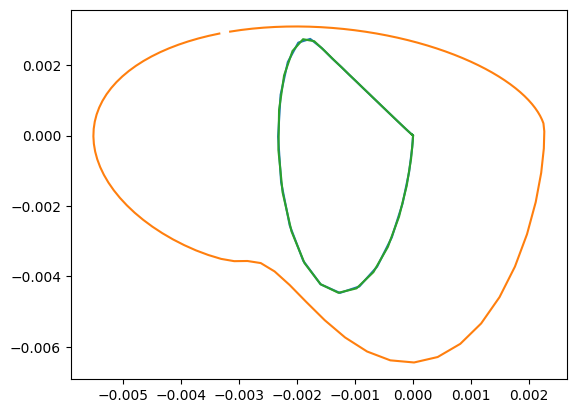

In [4]:
plt.figure()
plt.plot(FS_train[0, 0, :, 0], FS_train[0, 1, :, 0], label="1")
plt.plot(FS_train[1, 0, :, 10], FS_train[1, 1, :, 10], label="2")
plt.plot(FS_train[2, 0, :, 0], FS_train[2, 1, :, 0], label="3")
plt.show()

In [5]:
# Apply sensor placement
sp = sensor_processing(FS_train[:, 1], config_global)
cluster_matrix_subdir = os.path.join("compression_matrices", "clusters", str(cluster))
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(
    output_dir,
    matrix_subdir=cluster_matrix_subdir,
)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

# In vector_nodes mode, sparse width per field is
# number_of_selected_nodes * n_components
n_fields = RS_train.shape[1]              # should be 2: displacement, velocity
n_sparse_per_field = RS_train.shape[-1]

RS_train = np.concatenate([RS_train[:, i, :, :] for i in range(n_fields)], axis=-1)
RS_val = np.concatenate([RS_val[:, i, :, :] for i in range(n_fields)], axis=-1)
RS_test = np.concatenate([RS_test[:, i, :, :] for i in range(n_fields)], axis=-1)

config_global["sensors"]["n_sensors"] = int(n_sparse_per_field)
n_sparse = int(n_sparse_per_field)

RS_train = np.ascontiguousarray(RS_train, dtype=np.float32)
RS_val = np.ascontiguousarray(RS_val, dtype=np.float32)
RS_test = np.ascontiguousarray(RS_test, dtype=np.float32)
ft_train = np.ascontiguousarray(ft_train, dtype=np.float32)
ft_val = np.ascontiguousarray(ft_val, dtype=np.float32)
ft_test = np.ascontiguousarray(ft_test, dtype=np.float32)
FS_test = np.ascontiguousarray(FS_test, dtype=np.float32)
t_eval = np.ascontiguousarray(t[:, np.newaxis], dtype=np.float32)

del FS_train, FS_val
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("A_Mat shape:", A_Mat.shape)
print("C_Mat shape:", C_Mat.shape)
print("RS_test shape after reshape:", RS_test.shape)
print("n_sensors used by EDM:", config_global["sensors"]["n_sensors"])

A_Mat shape: (6650, 13)
C_Mat shape: (100, 6650)
RS_test shape after reshape: (64, 100, 200)
n_sensors used by EDM: 100


##### Load Model

model_params = os.path.join(chkpnt_path, "best_model_state_dict.pth")
state = torch.load(model_params, map_location=torch.device(device))

if model_backend is None:
    if any("mass_diag_raw" in key for key in state.keys()):
        model_backend = "EDM_v2"
    elif any(("grad_shape" in key) or ("sqrt_area" in key) for key in state.keys()):
        model_backend = "EDM_v1_1"
    else:
        model_backend = "EDM"

backend_registry = {
    "EDM": (
        EDM_v1,
        {
            "gate_config": "narrow",
            "method": "rbf_lpv_resid",
            "indx_q": 1,
        },
    ),
    "EDM_v1_1": (
        EDM_v1_1,
        {
            "method": "rbf_lpv_resid",
            "indx_q": 1,
        },
    ),
    "EDM_v2": (
        EDM_v2,
        {
            "method": "latent_mechanics",
            "indx_q": 1,
        },
    ),
}

if model_backend not in backend_registry:
    raise ValueError(f"Unknown model_backend: {model_backend}")

EDM_cls, build_kwargs = backend_registry[model_backend]
print(f"Detected checkpoint backend: {model_backend}")
model = EDM_cls(A_Mat, pinv_Theta, dt, T, config_global, device)

[EDM_v1_2] Using NODE variant: RBFHistoryMoE_NODE
[EDM_v1_2] Gate losses: balance=0.1, anchor=10.0, overlap=0.5, expert_diversity=0.005; target=0.333/0.333/0.333
[EDM_v1_2] CST gradient loss: grad_dim=49784, sparse_dim=200, dim_scale=0.0040, effective Q=0.482083


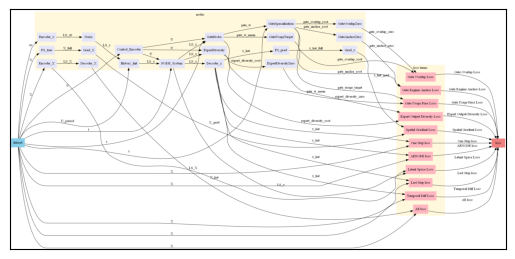

In [6]:
model = EDM(A_Mat, pinv_Theta, dt, T, config_global, device)
model.build_model(method="rbf_moe")

In [7]:
# Load model
model_params = os.path.abspath(os.path.join(output_dir, "model_checkpoint", str(cluster))) + "/best_model_state_dict.pth"
model.problem.load_state_dict(torch.load(model_params, map_location=torch.device(device)))

<All keys matched successfully>

In [8]:
model.problem.nodes[5].nsteps = nt
model.problem.eval()

### MODEL SUMMARY ###

NODES:
  Encoder_x(x0) -> LS_z0
  Encoder_X(X) -> LS_X
  Noise(LS_z0) -> LS_z
  Control_Encoder(U) -> U
  History_Init(LS_z, U_period) -> LS_x
  System(
  (nodes): ModuleList(
    (0): NODE(LS_x, U, t) -> LS_x
  )
)
  Decoder_x(LS_x) -> x_hat
  Decoder_X(LS_X) -> X_hat
  GateProbe(LS_x, U, t) -> gate_w, gate_w_mean
  GateUsageTarget(gate_w_mean) -> gate_usage_target
  GateSpecialization(gate_w, t) -> gate_anchor_root, gate_overlap_root
  GateAnchorZero(gate_anchor_root) -> gate_anchor_zero
  GateOverlapZero(gate_overlap_root) -> gate_overlap_zero
  ExpertDiversity(LS_x, U) -> expert_diversity_root
  ExpertDiversityZero(expert_diversity_root) -> expert_diversity_zero
  FS_true(X) -> X_full
  FS_pred(x_hat) -> x_hat_full
  Grad_X(X_full) -> X_grad
  Grad_x(x_hat_full) -> x_hat_grad

CONSTRAINTS: none

OBJECTIVES:
  Constraint(
  (left): slice
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): X_hat
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left)

##### Single-cycle evaluation

eval_count = min(64, RS_test.shape[0])
eval_idx = np.arange(eval_count)
RS_test_eval = np.ascontiguousarray(RS_test[eval_idx], dtype=np.float32)
ft_test_eval = np.ascontiguousarray(ft_test[eval_idx], dtype=np.float32)

test_t = torch.as_tensor(t_eval, dtype=torch.float32, device=device)
test_data = {
    "X": torch.as_tensor(RS_test_eval, dtype=torch.float32, device=device),
    "x0": torch.as_tensor(RS_test_eval[:, 0:1], dtype=torch.float32, device=device),
    "U": torch.as_tensor(ft_test_eval, dtype=torch.float32, device=device),
    "t": test_t.repeat(eval_count, 1, 1),
}
outputs = model.problem.step(test_data)

In [9]:
t_eval = np.ascontiguousarray(t[:, np.newaxis], dtype=np.float32)
RS_test_eval = np.ascontiguousarray(RS_test, dtype=np.float32)
ft_test_eval = np.ascontiguousarray(ft_test, dtype=np.float32)

test_t = torch.as_tensor(t_eval, dtype=torch.float32, device=device)
test_data = {
    "X": torch.as_tensor(RS_test_eval, dtype=torch.float32, device=device),
    "x0": torch.as_tensor(RS_test_eval[:, 0:1], dtype=torch.float32, device=device),
    "U": torch.as_tensor(ft_test_eval, dtype=torch.float32, device=device),
    "t": test_t.repeat(RS_test_eval.shape[0], 1, 1),
    "U_period": torch.as_tensor(ft_test_eval, dtype=torch.float32, device=device)
}
outputs = model.problem.step(test_data)

In [10]:
eval_count = min(64, RS_test.shape[0])
eval_idx = np.arange(eval_count)

In [11]:
# Flatten true full-state data:
# [n_samples, 2, nt, ndof] -> [n_samples, nt, 2*ndof]
#FS_test = FS_test[:64]
n_samples, n_fields, nt_data, ndof = FS_test.shape
FS_reshaped = np.concatenate([FS_test[:, i, :, :] for i in range(n_fields)], axis=-1)
RS_reshaped = RS_test
FS_reshaped_eval = FS_reshaped[eval_idx]
RS_reshaped_eval = RS_reshaped[eval_idx]

# Decoder outputs live in sparse space unless the graph explicitly adds
# full-space lift nodes.  EDM_v1_1 exposes x_hat_full for NODE rollout,
# but AE reconstruction remains sparse unless X_hat_full is present.
FS_AE_sparse = outputs["X_hat"][eval_idx].cpu().detach().numpy()
FS_AE_full = outputs["X_hat_full"][eval_idx].cpu().detach().numpy() if "X_hat_full" in outputs else None

if "x_hat_full" in outputs:
    FS_pred = outputs["x_hat_full"][eval_idx, :-1, :].cpu().detach().numpy()
else:
    FS_pred = outputs["x_hat"][eval_idx, :-1, :].cpu().detach().numpy()

mesh_json_path = os.path.abspath(os.path.join(script_dir, "..", "Step_00_Create_Data", "beam_ellipse_shared.json"))
with open(mesh_json_path, "r") as f:
    mesh_meta = json.load(f)

node_labels = mesh_meta["node_labels"]
top_sample_labels = mesh_meta["top_sample_node_labels"]
top_sample_x = np.asarray(mesh_meta["top_sample_x"], dtype=np.float32)
label_to_index = {label: i for i, label in enumerate(node_labels)}

n_components = int(config_global.get("sensors", {}).get("n_components", 2))
dof_layout = config_global["sensors"].get("dof_layout", "interleaved")
n_nodes = ndof // n_components

def field_component_index(field_offset, node_index, component):
    if dof_layout == "interleaved":
        local = n_components * node_index + component
    else:
        local = component * n_nodes + node_index
    return field_offset + local

disp_offset = 0
vel_offset = ndof
plot_top_idx = int(len(top_sample_labels) // 1.333)
plot_node_label = top_sample_labels[plot_top_idx]
plot_node_idx = label_to_index[plot_node_label]
plot_x_coord = float(top_sample_x[plot_top_idx])
plot_component = 1  # 0 = x, 1 = y
plot_component_name = "y" if plot_component == 1 else "x"

disp_idx = field_component_index(disp_offset, plot_node_idx, plot_component)
vel_idx = field_component_index(vel_offset, plot_node_idx, plot_component)

print("FS_reshaped shape:", FS_reshaped.shape)
print("FS_AE_sparse shape:", FS_AE_sparse.shape)
print("FS_AE_full shape:", None if FS_AE_full is None else FS_AE_full.shape)
print("FS_pred shape:", FS_pred.shape)
print(f"Plotting node label {plot_node_label} at x={plot_x_coord:.3f}, component={plot_component_name}")


FS_reshaped shape: (64, 100, 13300)
FS_AE_sparse shape: (64, 100, 200)
FS_AE_full shape: None
FS_pred shape: (64, 100, 13300)
Plotting node label 303 at x=0.750, component=y


In [12]:
ae_sparse_frob_error = np.linalg.norm(FS_AE_sparse - RS_reshaped_eval) / np.linalg.norm(RS_reshaped_eval)
ae_full_frob_error = None
if FS_AE_full is not None:
    ae_full_frob_error = np.linalg.norm(FS_AE_full - FS_reshaped_eval) / np.linalg.norm(FS_reshaped_eval)
node_full_frob_error = np.linalg.norm(FS_pred - FS_reshaped_eval) / np.linalg.norm(FS_reshaped_eval)

if ae_full_frob_error is not None:
    print(f"Frob norm for AE (full space) is : {ae_full_frob_error}")
else:
    print(f"Frob norm for AE (sparse space) is : {ae_sparse_frob_error}")
print(f"Frob norm for NODE (full space) is : {node_full_frob_error}")

Frob norm for AE (sparse space) is : 0.020212821662425995
Frob norm for NODE (full space) is : 0.01969546638429165


In [13]:
errs = np.zeros((eval_count,))
for i in range(eval_count):
    errs[i] = np.linalg.norm(FS_pred[i] - FS_reshaped_eval[i]) / np.linalg.norm(FS_reshaped_eval[i])

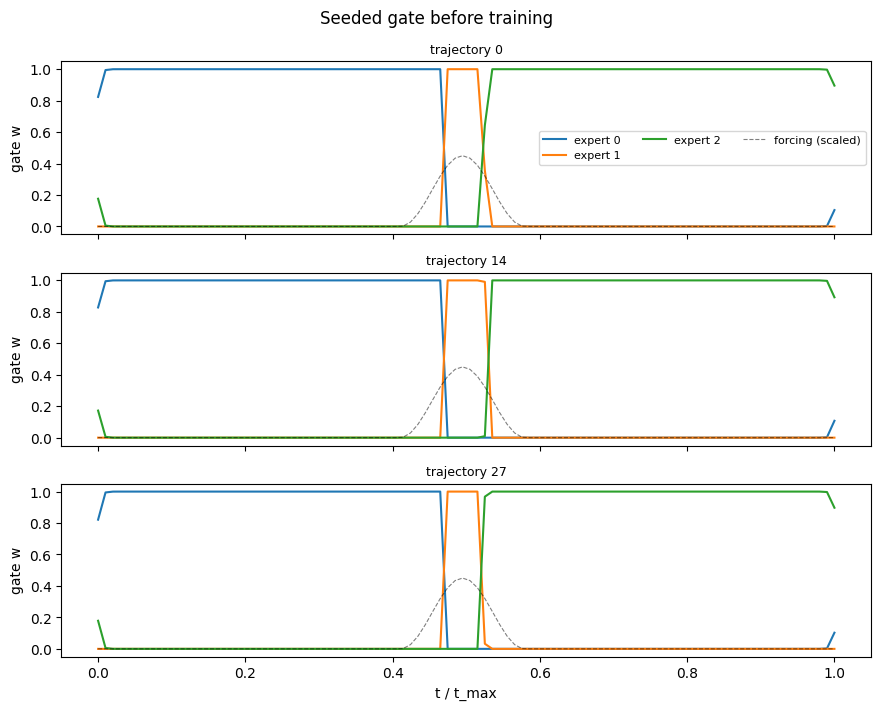

In [16]:
t_max = T
@torch.no_grad()
def gate_weights_over_time(model, ft):
    """Gate weights using the same periodic history initialization as training."""
    node = model._gate_node
    U = torch.as_tensor(ft, dtype=torch.float32, device=model.device)
    if U.ndim == 2:
        U = U.unsqueeze(0)
    feats = node.gate_feature_samples(U, flatten=False)
    return node.gate(feats).cpu().numpy()


def plot_gate_weights(model, ft, t, title="Current gate weights"):
    W = gate_weights_over_time(model, ft)
    t_norm = np.asarray(t).reshape(-1) / t_max
    idxs = sorted(set([0, len(ft)//2, len(ft)-1]))
    fig, axes = plt.subplots(len(idxs), 1, figsize=(9, 2.4*len(idxs)), sharex=True)
    axes = np.atleast_1d(axes)
    for row, (ax, i) in enumerate(zip(axes, idxs)):
        for k in range(W.shape[-1]):
            ax.plot(t_norm, W[i, :, k], lw=1.5,
                    label=f"expert {k}" if row == 0 else None)
        u0 = ft[i, :, 0]
        scale = max(float(np.max(np.abs(u0))), 1e-12)
        ax.plot(t_norm, 0.45*u0/scale, "k--", lw=0.8, alpha=0.5,
                label="forcing (scaled)" if row == 0 else None)
        ax.set_ylabel("gate w")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"trajectory {i}", fontsize=9)
    axes[0].legend(ncol=3, fontsize=8)
    axes[-1].set_xlabel("t / t_max")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return W

# This is the seeded, pre-training gate.  The same function is called again after training.
W = plot_gate_weights(model, ft_train, t, title="Seeded gate before training")


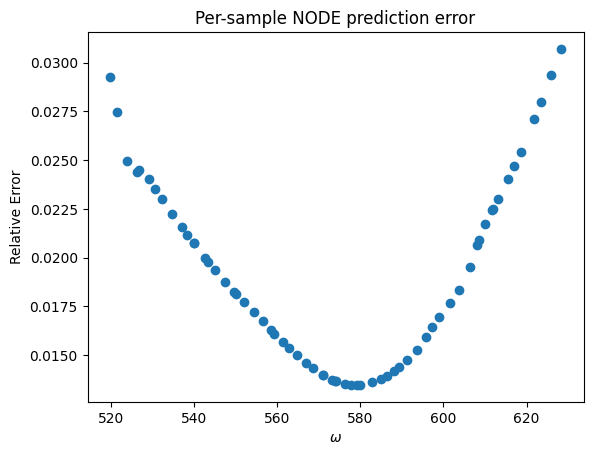

In [17]:
plt.figure(dpi=100)
plt.scatter(params_test[eval_idx, 0], errs, marker='o')
plt.xlabel(r"$\omega$")
plt.ylabel("Relative Error")
plt.title("Per-sample NODE prediction error")
plt.show()

Raw node error min: 0.0
Raw node error max: 0.5897500583529185
Color range used (1-99 percentile): 0.01790267234528222 0.11860543188777614
Error percentiles [0, 1, 5, 50, 95, 99, 100]: [0.         0.01790267 0.01796385 0.0265087  0.06957289 0.11860543
 0.58975006]


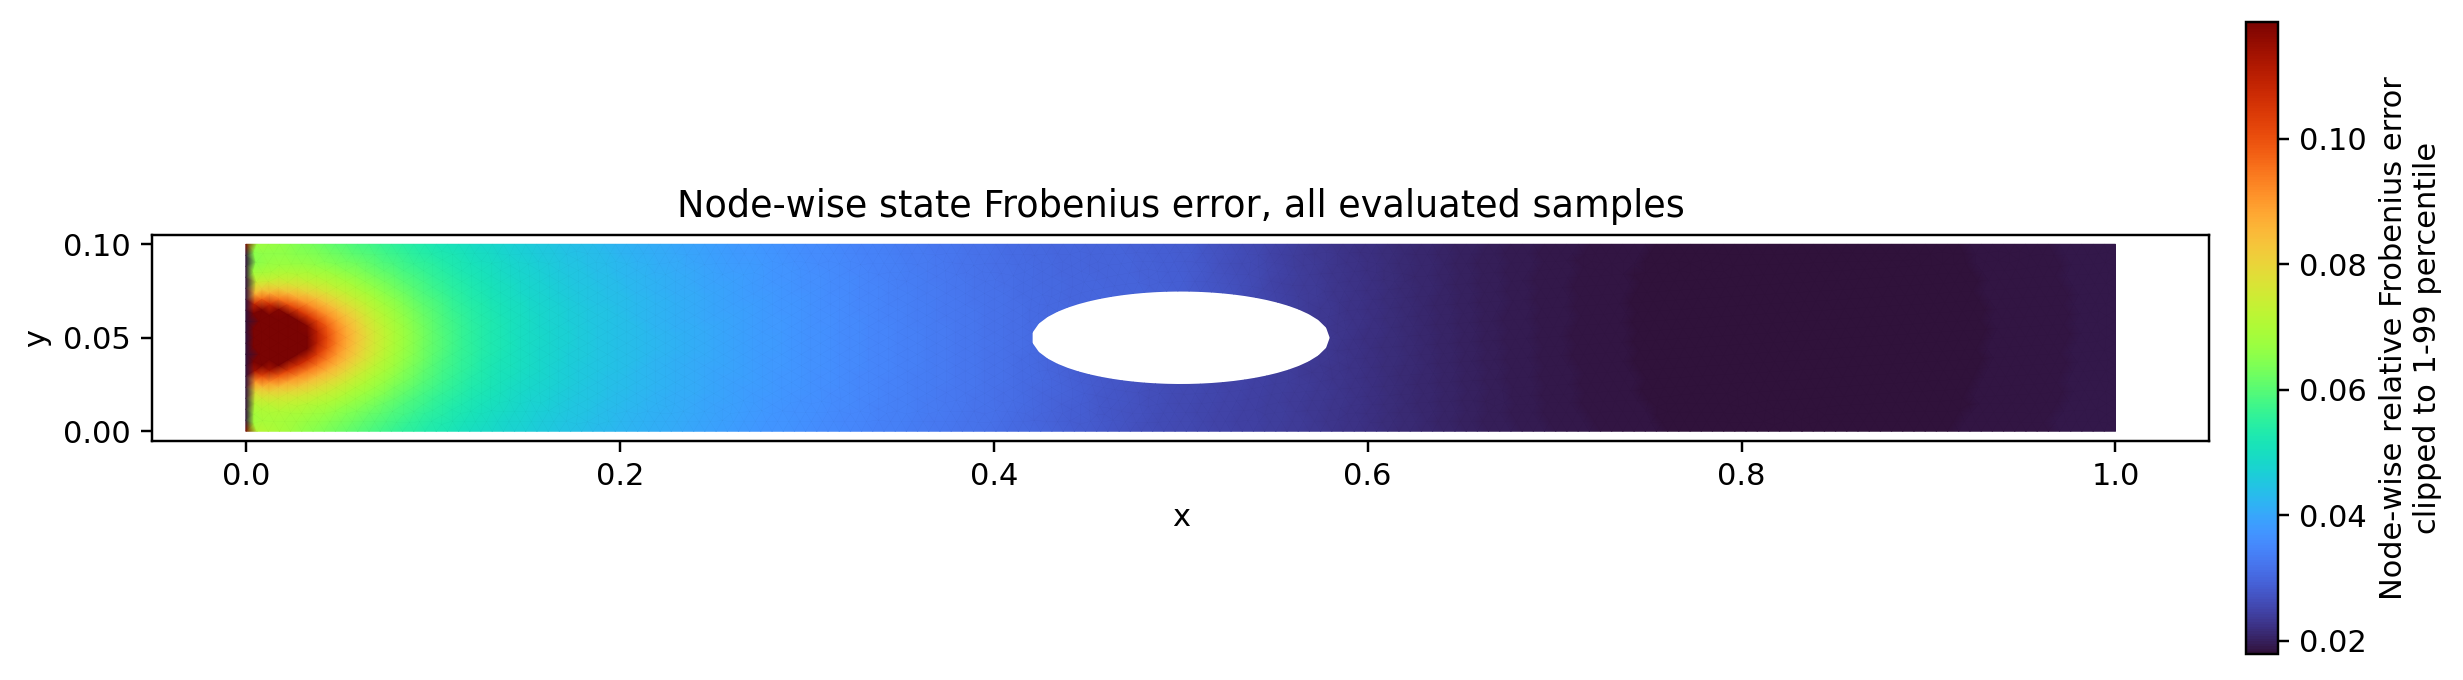

In [18]:
# Node-wise relative Frobenius error plotted as a robust gradient on the FEA mesh.
#
# Required variables from earlier notebook cells:
#   FS_reshaped : [n_samples, nt, 2 * ndof] true full state
#   FS_pred     : [n_samples, nt, 2 * ndof] predicted full state
#   mesh_meta   : dictionary loaded from beam_ellipse_shared.json
#   ndof
#   n_components
#   dof_layout

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# -----------------------------
# Settings
# -----------------------------

# Use an integer for one test sample, e.g. sample_idx = 0.
# Use None to aggregate the Frobenius norm over all evaluated samples.
sample_idx = None

# Choose what to include at each node:
#   "disp"  -> ux, uy displacement only
#   "vel"   -> vx, vy velocity only
#   "state" -> ux, uy, vx, vy
field_to_plot = "state"

# Percentile color clipping.
# This prevents a few very large relative errors from washing out the whole plot.
clip_low = 1
clip_high = 99

# Colormap options: "turbo", "viridis", "plasma", "inferno", "hot_r"
cmap_name = "turbo"

# Set True if you want subtle mesh lines on top of the gradient.
show_mesh_lines = True

# -----------------------------
# Mesh setup
# -----------------------------
coords = np.asarray(mesh_meta["coords"], dtype=float)[:, :2]
node_labels_arr = np.asarray(mesh_meta["node_labels"], dtype=int)
tri_labels = np.asarray(mesh_meta["tri3_connectivity_labels"], dtype=int)

label_to_idx = {int(lbl): i for i, lbl in enumerate(node_labels_arr)}
tri_conn = np.asarray(
    [[label_to_idx[int(lbl)] for lbl in elem] for elem in tri_labels],
    dtype=int,
)

x = coords[:, 0]
y = coords[:, 1]
n_nodes = coords.shape[0]
triang = mtri.Triangulation(x, y, tri_conn)

# -----------------------------
# DOF helpers
# -----------------------------
def node_dof_indices(node_idx, components=(0, 1)):
    """
    Return local DOF indices inside one field block.

    For displacement block:
        ux, uy indices live in [0, ndof)

    For velocity block:
        vx, vy indices live in [ndof, 2 * ndof)
    """
    if dof_layout == "interleaved":
        return [n_components * node_idx + comp for comp in components]

    if dof_layout == "blocked":
        return [comp * n_nodes + node_idx for comp in components]

    raise ValueError(f"Unknown dof_layout: {dof_layout}")


def selected_state_cols(node_idx, field="state"):
    """
    Return flattened FS_reshaped / FS_pred column indices for one node.
    """
    comp_idx = node_dof_indices(node_idx, components=(0, 1))

    cols = []

    if field in ("disp", "state"):
        cols.extend(comp_idx)

    if field in ("vel", "state"):
        cols.extend([ndof + j for j in comp_idx])

    if len(cols) == 0:
        raise ValueError("field must be one of: 'disp', 'vel', 'state'")

    return cols

# -----------------------------
# Select samples
# -----------------------------
true_eval = FS_reshaped[:FS_pred.shape[0]]
pred_eval = FS_pred

if sample_idx is None:
    true_sel = true_eval
    pred_sel = pred_eval
    title_sample = "all evaluated samples"
else:
    true_sel = true_eval[sample_idx:sample_idx + 1]
    pred_sel = pred_eval[sample_idx:sample_idx + 1]
    title_sample = f"sample {sample_idx}"

# -----------------------------
# Node-wise Frobenius error
# -----------------------------
node_abs_err = np.zeros(n_nodes, dtype=float)
node_true_norm = np.zeros(n_nodes, dtype=float)

for node_idx in range(n_nodes):
    cols = selected_state_cols(node_idx, field_to_plot)

    true_node = true_sel[:, :, cols]
    pred_node = pred_sel[:, :, cols]

    node_abs_err[node_idx] = np.linalg.norm(pred_node - true_node)
    node_true_norm[node_idx] = np.linalg.norm(true_node)

# Pure relative L2 (Frobenius) error: ||pred - true|| / ||true||
with np.errstate(divide="ignore", invalid="ignore"):
    node_frob_err = node_abs_err / node_true_norm

# Remove non-finite values defensively.
node_frob_err = np.nan_to_num(
    node_frob_err,
    nan=0.0,
    posinf=np.nanmax(node_frob_err[np.isfinite(node_frob_err)]),
    neginf=0.0,
)

# -----------------------------
# Robust color scaling
# -----------------------------
finite_err = node_frob_err[np.isfinite(node_frob_err)]

vmin, vmax = np.percentile(finite_err, [clip_low, clip_high])

if np.isclose(vmin, vmax):
    vmin = finite_err.min()
    vmax = finite_err.max()

node_frob_err_plot = np.clip(node_frob_err, vmin, vmax)

print("Raw node error min:", np.nanmin(node_frob_err))
print("Raw node error max:", np.nanmax(node_frob_err))
print(f"Color range used ({clip_low}-{clip_high} percentile):", vmin, vmax)
print(
    "Error percentiles [0, 1, 5, 50, 95, 99, 100]:",
    np.percentile(finite_err, [0, 1, 5, 50, 95, 99, 100]),
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 3.2), dpi=220)

tpc = ax.tripcolor(
    triang,
    node_frob_err_plot,
    shading="gouraud",
    cmap=cmap_name,
    vmin=vmin,
    vmax=vmax,
)

if show_mesh_lines:
    ax.triplot(
        triang,
        color="k",
        linewidth=0.05,
        alpha=0.08,
    )

cbar = plt.colorbar(tpc, ax=ax, pad=0.015)
cbar.set_label(
    f"Node-wise relative Frobenius error\n"
    f"clipped to {clip_low}-{clip_high} percentile"
)

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    f"Node-wise {field_to_plot} Frobenius error, {title_sample}"
)

plt.tight_layout()
plt.show()


Raw node MSE min: 0.0
Raw node MSE max: 4.26627229899168e-05
Color range used (1-99 percentile): 2.429864903730207e-10 4.130800210987217e-05
MSE percentiles [0, 1, 5, 50, 95, 99, 100]: [0.00000000e+00 2.42986490e-10 2.19282040e-08 1.06653551e-05
 3.57125093e-05 4.13080021e-05 4.26627230e-05]
Global MSE (over all selected samples/timesteps/dofs): 1.2092824e-05


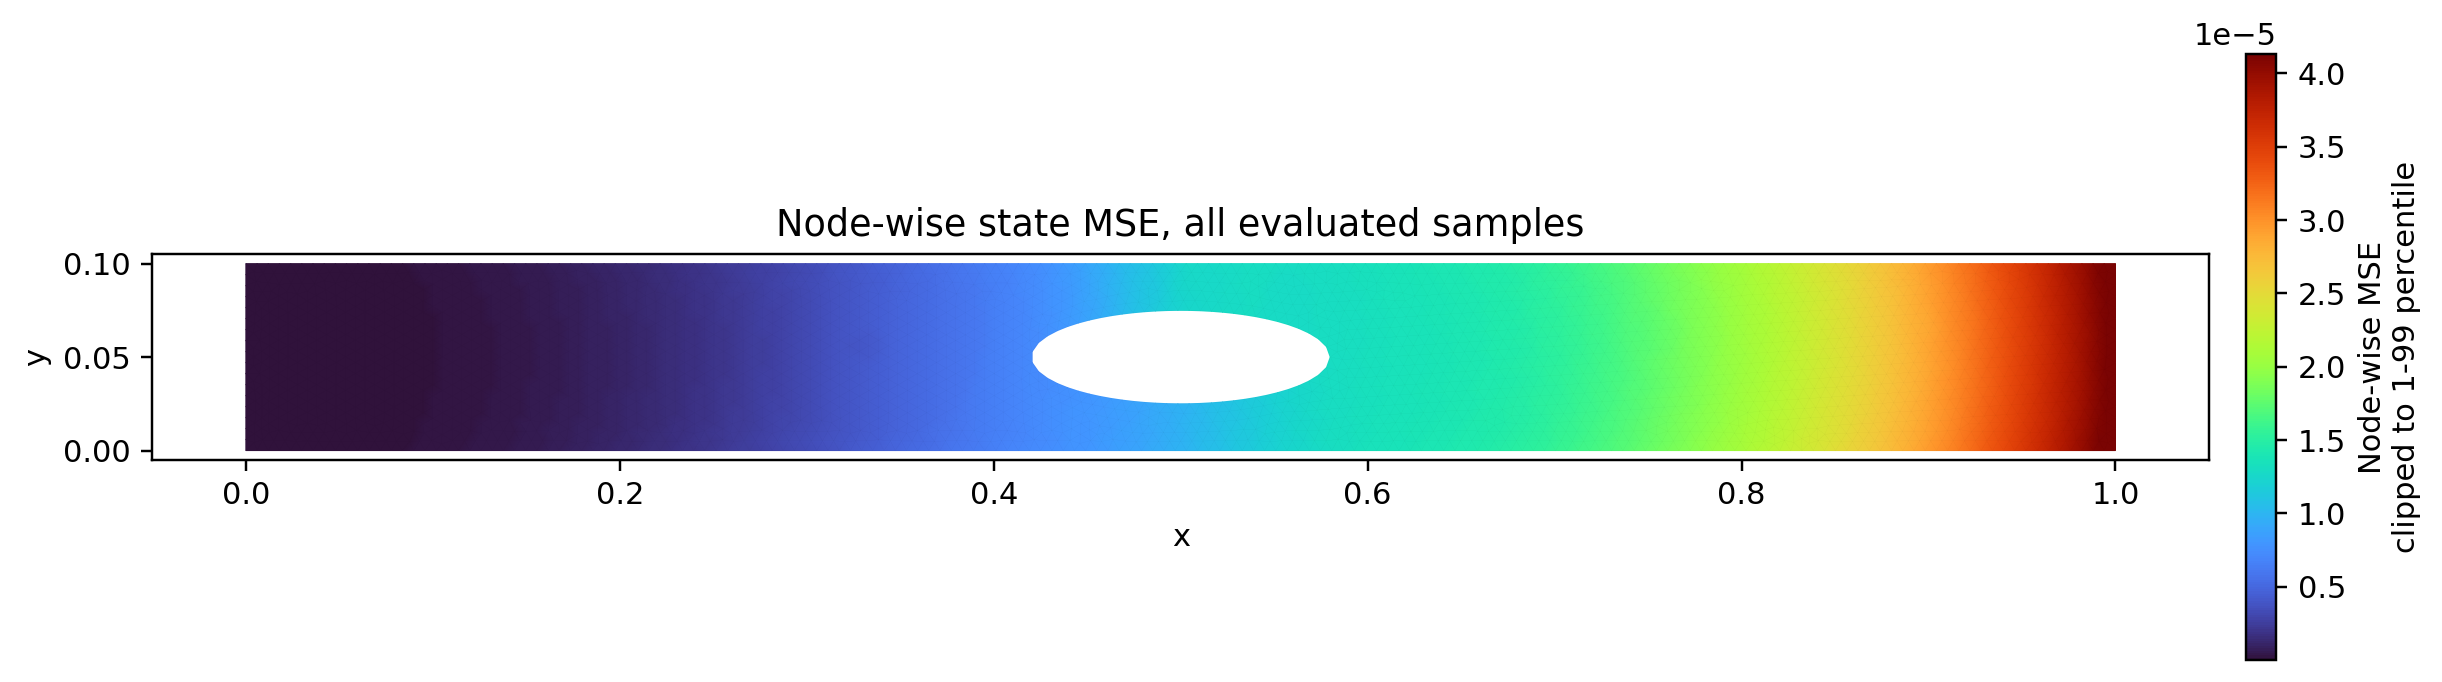

In [19]:
# Node-wise MSE plotted as a robust gradient on the FEA mesh.
#
# Required variables from earlier notebook cells:
#   FS_reshaped : [n_samples, nt, 2 * ndof] true full state
#   FS_pred     : [n_samples, nt, 2 * ndof] predicted full state
#   mesh_meta   : dictionary loaded from beam_ellipse_shared.json
#   ndof
#   n_components
#   dof_layout

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# -----------------------------
# Settings
# -----------------------------

# Use an integer for one test sample, e.g. sample_idx = 0.
# Use None to aggregate the MSE over all evaluated samples.
sample_idx = None

# Choose what to include at each node:
#   "disp"  -> ux, uy displacement only
#   "vel"   -> vx, vy velocity only
#   "state" -> ux, uy, vx, vy
field_to_plot = "state"

# Percentile color clipping.
# This prevents a few very large MSE values from washing out the whole plot.
clip_low = 1
clip_high = 99

# Colormap options: "turbo", "viridis", "plasma", "inferno", "hot_r"
cmap_name = "turbo"

# Set True if you want subtle mesh lines on top of the gradient.
show_mesh_lines = True

# -----------------------------
# Mesh setup
# -----------------------------
coords = np.asarray(mesh_meta["coords"], dtype=float)[:, :2]
node_labels_arr = np.asarray(mesh_meta["node_labels"], dtype=int)
tri_labels = np.asarray(mesh_meta["tri3_connectivity_labels"], dtype=int)

label_to_idx = {int(lbl): i for i, lbl in enumerate(node_labels_arr)}
tri_conn = np.asarray(
    [[label_to_idx[int(lbl)] for lbl in elem] for elem in tri_labels],
    dtype=int,
)

x = coords[:, 0]
y = coords[:, 1]
n_nodes = coords.shape[0]
triang = mtri.Triangulation(x, y, tri_conn)

# -----------------------------
# DOF helpers
# -----------------------------
def node_dof_indices(node_idx, components=(0, 1)):
    """
    Return local DOF indices inside one field block.

    For displacement block:
        ux, uy indices live in [0, ndof)

    For velocity block:
        vx, vy indices live in [ndof, 2 * ndof)
    """
    if dof_layout == "interleaved":
        return [n_components * node_idx + comp for comp in components]

    if dof_layout == "blocked":
        return [comp * n_nodes + node_idx for comp in components]

    raise ValueError(f"Unknown dof_layout: {dof_layout}")


def selected_state_cols(node_idx, field="state"):
    """
    Return flattened FS_reshaped / FS_pred column indices for one node.
    """
    comp_idx = node_dof_indices(node_idx, components=(0, 1))

    cols = []

    if field in ("disp", "state"):
        cols.extend(comp_idx)

    if field in ("vel", "state"):
        cols.extend([ndof + j for j in comp_idx])

    if len(cols) == 0:
        raise ValueError("field must be one of: 'disp', 'vel', 'state'")

    return cols

# -----------------------------
# Select samples
# -----------------------------
true_eval = FS_reshaped[:FS_pred.shape[0]]
pred_eval = FS_pred

if sample_idx is None:
    true_sel = true_eval
    pred_sel = pred_eval
    title_sample = "all evaluated samples"
else:
    true_sel = true_eval[sample_idx:sample_idx + 1]
    pred_sel = pred_eval[sample_idx:sample_idx + 1]
    title_sample = f"sample {sample_idx}"

# -----------------------------
# Node-wise MSE
# -----------------------------
# At each node: MSE = mean of (pred - true)^2 across samples, timesteps,
# and the selected components (e.g. ux, uy, vx, vy).
node_mse = np.zeros(n_nodes, dtype=float)

for node_idx in range(n_nodes):
    cols = selected_state_cols(node_idx, field_to_plot)

    true_node = true_sel[:, :, cols]
    pred_node = pred_sel[:, :, cols]

    node_mse[node_idx] = np.mean((pred_node - true_node) ** 2)

# Remove non-finite values defensively.
node_mse = np.nan_to_num(
    node_mse,
    nan=0.0,
    posinf=np.nanmax(node_mse[np.isfinite(node_mse)]) if np.any(np.isfinite(node_mse)) else 0.0,
    neginf=0.0,
)

# -----------------------------
# Robust color scaling
# -----------------------------
finite_err = node_mse[np.isfinite(node_mse)]

vmin, vmax = np.percentile(finite_err, [clip_low, clip_high])

if np.isclose(vmin, vmax):
    vmin = finite_err.min()
    vmax = finite_err.max()

node_mse_plot = np.clip(node_mse, vmin, vmax)

print("Raw node MSE min:", np.nanmin(node_mse))
print("Raw node MSE max:", np.nanmax(node_mse))
print(f"Color range used ({clip_low}-{clip_high} percentile):", vmin, vmax)
print(
    "MSE percentiles [0, 1, 5, 50, 95, 99, 100]:",
    np.percentile(finite_err, [0, 1, 5, 50, 95, 99, 100]),
)

# Also report the global MSE for reference (mean over all entries).
global_mse = np.mean((pred_sel - true_sel) ** 2)
print("Global MSE (over all selected samples/timesteps/dofs):", global_mse)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 3.2), dpi=220)

tpc = ax.tripcolor(
    triang,
    node_mse_plot,
    shading="gouraud",
    cmap=cmap_name,
    vmin=vmin,
    vmax=vmax,
)

if show_mesh_lines:
    ax.triplot(
        triang,
        color="k",
        linewidth=0.05,
        alpha=0.08,
    )

cbar = plt.colorbar(tpc, ax=ax, pad=0.015)
cbar.set_label(
    f"Node-wise MSE\n"
    f"clipped to {clip_low}-{clip_high} percentile"
)

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    f"Node-wise {field_to_plot} MSE, {title_sample}"
)

plt.tight_layout()
plt.show()

In [20]:
# Export helpers for 2D evaluation plotting bundles.
evaluation_plot_data_dir = os.path.join(chkpnt_path, "evaluation_plot_data")


def _json_safe(value):
    if isinstance(value, torch.Tensor):
        return _json_safe(value.detach().cpu().numpy())
    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return _json_safe(value.item())
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(key): _json_safe(val) for key, val in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


def _as_export_array(value):
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().numpy()
    elif isinstance(value, np.generic):
        value = value.item()
    return np.asarray(value)


def _array_summary(arr):
    arr = np.asarray(arr)
    return {"shape": list(arr.shape), "dtype": str(arr.dtype)}


def _collect_evaluation_plot_arrays(scope):
    export_names = [
        "t", "t_eval", "T", "dt", "t_long", "t_cycle",
        "eval_idx", "RS_train", "RS_val", "RS_test", "RS_test_eval", "ft_train", "ft_val", "ft_test", "ft_test_eval",
        "params_train", "params_val", "params_test", "disp_norm", "vel_norm", "ft_norm",
        "A_Mat", "C_Mat", "pinv_Theta", "sensor_placement", "C_recon",
        "gate_centers", "gate_sigma", "gate_weights", "q_grid", "rbf_weights",
        "FS_reshaped", "FS_reshaped_eval", "RS_reshaped", "RS_reshaped_eval", "FS_AE_sparse", "FS_AE_full", "FS_AE_pred", "FS_pred", "errs",
        "idx", "num_cycles", "RS_test_long", "ft_test_long", "RS_reshaped_long", "FS_reshaped_long", "FS_AE_long_sparse", "FS_AE_long_full", "FS_pred_long",
        "F_true", "Pxx_true", "F_pred", "Pxx_pred", "psd_time",
        "coords", "tri_conn", "node_labels_arr", "top_sample_x", "node_frob_err", "node_frob_err_plot", "node_mse", "node_mse_plot",
        "disp_idx", "vel_idx", "plot_node_idx", "plot_component", "p", "ind", "lim", "ae_errs", "par_ae_errs", "sparse_ae_errs",
        "sensorloc", "sparse_sensor", "sparse_par",
    ]
    arrays = {}
    missing = []
    for name in export_names:
        if name not in scope or scope[name] is None:
            missing.append(name)
            continue
        arrays[name] = _as_export_array(scope[name])
    return arrays, missing


def write_evaluation_plot_bundle(scope):
    os.makedirs(evaluation_plot_data_dir, exist_ok=True)
    plot_arrays, missing_arrays = _collect_evaluation_plot_arrays(scope)

    npz_path = os.path.join(evaluation_plot_data_dir, "evaluation_plot_data.npz")
    np.savez_compressed(npz_path, **plot_arrays)

    array_summaries = {name: _array_summary(arr) for name, arr in plot_arrays.items()}
    metadata = {
        "cluster": int(cluster),
        "chkpnt_path": os.path.abspath(chkpnt_path),
        "evaluation_plot_data_dir": os.path.abspath(evaluation_plot_data_dir),
        "model_params": os.path.abspath(model_params),
        "config_file": os.path.abspath(config_file),
        "model_backend": model_backend,
        "cluster_matrix_subdir": cluster_matrix_subdir,
        "n_fields": int(n_fields),
        "n_sparse_per_field": int(n_sparse_per_field),
        "n_sparse": int(n_sparse),
        "nx": int(nx),
        "nt": int(nt),
        "ndof": int(ndof),
        "n_components": int(n_components),
        "n_nodes": int(n_nodes),
        "dof_layout": dof_layout,
        "scalar_error_metrics": {
            "ae_sparse_frob_error": ae_sparse_frob_error,
            "ae_full_frob_error": ae_full_frob_error,
            "node_full_frob_error": node_full_frob_error,
            "long_ae_sparse_frob_error": long_ae_sparse_frob_error,
            "long_ae_full_frob_error": long_ae_full_frob_error,
            "long_node_full_frob_error": long_node_full_frob_error,
        },
        "selected_plot_node": {
            "plot_node_label": int(plot_node_label),
            "plot_node_idx": int(plot_node_idx),
            "plot_x_coord": float(plot_x_coord),
            "plot_component": int(plot_component),
            "plot_component_name": plot_component_name,
            "disp_idx": int(disp_idx),
            "vel_idx": int(vel_idx),
        },
        "mesh_metadata_path": os.path.abspath(mesh_json_path),
        "array_summaries": array_summaries,
        "missing_arrays": missing_arrays,
        "source_dataset_paths": {
            "Train": os.path.abspath(os.path.join(output_dir, "datasets", "Train", str(cluster))),
            "Val": os.path.abspath(os.path.join(output_dir, "datasets", "Val", str(cluster))),
            "Test": os.path.abspath(os.path.join(output_dir, "datasets", "Test", str(cluster))),
        },
        "config_global": config_global,
    }

    metadata_path = os.path.join(evaluation_plot_data_dir, "evaluation_plot_metadata.json")
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(_json_safe(metadata), f, indent=2)

    print(f"Saved evaluation plotting arrays to {npz_path}")
    print(f"Saved evaluation plotting metadata to {metadata_path}")
    if missing_arrays:
        print(f"Skipped missing arrays: {missing_arrays}")

    return {"npz_path": npz_path, "metadata_path": metadata_path, "missing_arrays": missing_arrays}


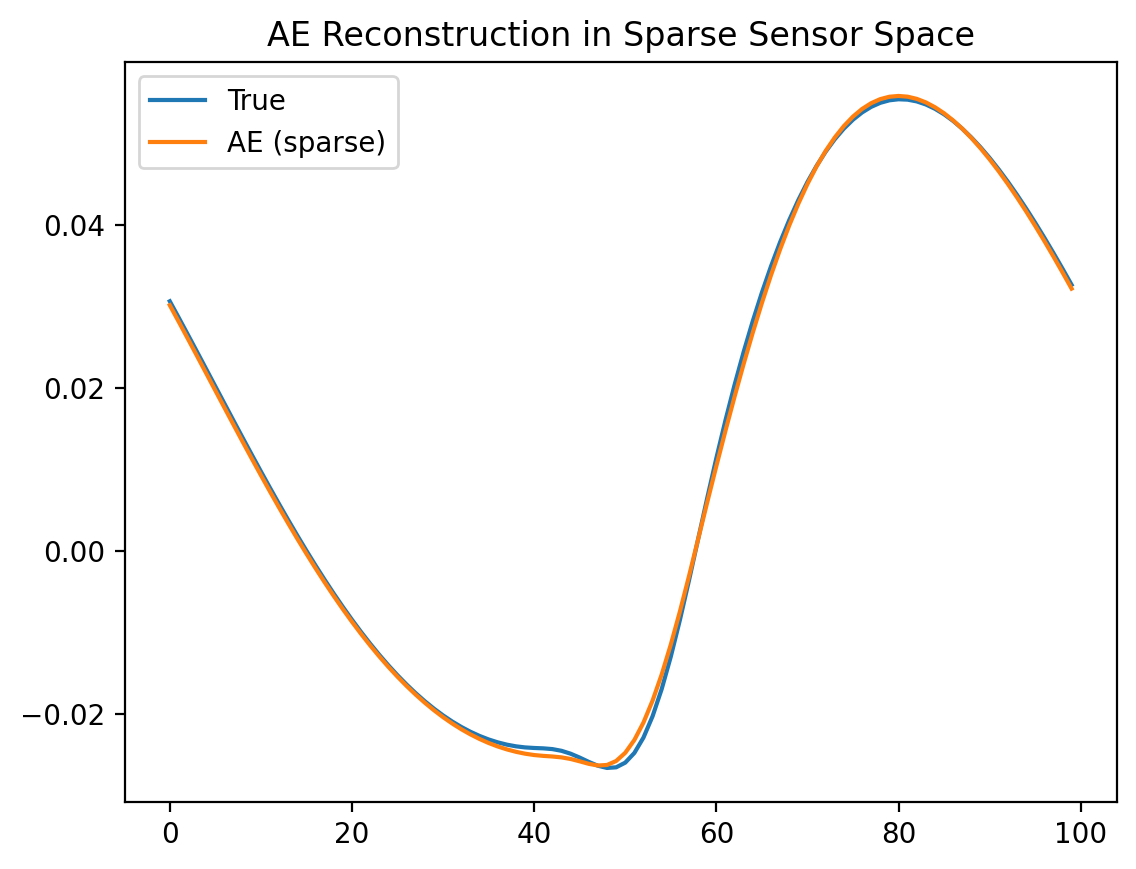

In [21]:
par = 1
plt.figure(dpi=200)
plt.plot(RS_reshaped[par, :, 0], label="True")
plt.plot(FS_AE_sparse[par, :, 0], label="AE (sparse)")
plt.legend()
plt.title("AE Reconstruction in Sparse Sensor Space")
plt.show()

In [22]:
C_recon = (A_Mat @ pinv_Theta).T

In [23]:
RS1 = FS_AE_sparse[:, :, : n_sparse_per_field]
RS2 = FS_AE_sparse[:, :, n_sparse_per_field :]
FS1 = RS1 @ C_recon
FS2 = RS2 @ C_recon

In [24]:
FS_AE_pred = np.concatenate([FS1, FS2], axis=-1)

In [25]:
ae_errs = np.array([
       np.linalg.norm(FS_AE_pred[i] - FS_reshaped_eval[i]) / np.linalg.norm(FS_reshaped_eval[i])
       for i in range(eval_count)
   ])
print(ae_errs)

[0.01776942 0.01614807 0.01232529 0.01600075 0.01199332 0.01242374
 0.01532865 0.01305403 0.01508673 0.01398509 0.01349712 0.01454554
 0.01337797 0.01178571 0.01688126 0.0118593  0.01664944 0.01731991
 0.01753205 0.01628276 0.01201933 0.01721265 0.01178361 0.01298653
 0.01502737 0.01396017 0.01364313 0.01460597 0.01338928 0.01568409
 0.01210351 0.01183192 0.01634184 0.01256235 0.01564929 0.01796265
 0.01787971 0.01540046 0.01243826 0.01648033 0.01189232 0.01224563
 0.01586501 0.01320541 0.01432867 0.01382128 0.01418606 0.01480427
 0.01283519 0.01180831 0.01705473 0.01214425 0.01649005 0.01762933
 0.01744441 0.01687551 0.01191161 0.01675928 0.01177631 0.01313675
 0.01434536 0.01368993 0.01425547 0.01489479]


In [26]:
par = np.argmax(ae_errs)

In [27]:
par_ae_errs = np.array([
       np.linalg.norm(FS_AE_pred[par, :, i] - FS_reshaped[par, :, i]) / np.linalg.norm(FS_reshaped[par, :, i])
       for i in range(FS_reshaped.shape[2])
   ])
par_ae_errs = np.nan_to_num(par_ae_errs, nan=0.0, posinf=0.0, neginf=0.0)

C:\Users\haida\AppData\Local\Temp\ipykernel_34720\85484358.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  np.linalg.norm(FS_AE_pred[par, :, i] - FS_reshaped[par, :, i]) / np.linalg.norm(FS_reshaped[par, :, i])
C:\Users\haida\AppData\Local\Temp\ipykernel_34720\85484358.py:2: RuntimeWarning: invalid value encountered in scalar divide
  np.linalg.norm(FS_AE_pred[par, :, i] - FS_reshaped[par, :, i]) / np.linalg.norm(FS_reshaped[par, :, i])


In [28]:
sensorloc = np.argmax(par_ae_errs)

In [29]:
np.linalg.norm(FS_AE_pred[par, :, sensorloc] - FS_reshaped[par, :, sensorloc]) / np.linalg.norm(FS_reshaped[par, :, sensorloc])

4.484584456925841

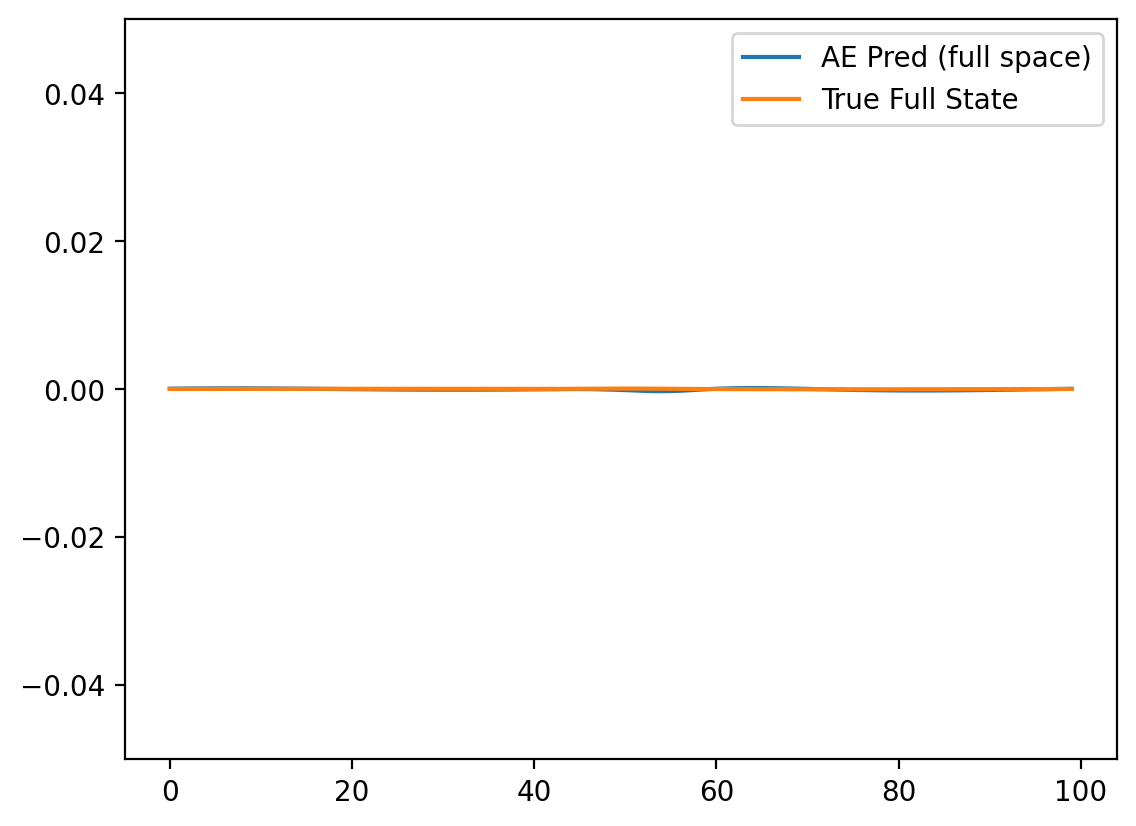

In [30]:
plt.figure(dpi=200)
plt.plot(FS_AE_pred[par, :, sensorloc], label="AE Pred (full space)")
plt.plot(FS_reshaped[par, :, sensorloc], label="True Full State")
plt.ylim(-0.05, 0.05)
plt.legend()
plt.show()

In [31]:
sparse_ae_errs = np.array([
       np.linalg.norm(FS_AE_sparse[i] - RS_reshaped_eval[i]) / np.linalg.norm(RS_reshaped_eval[i])
       for i in range(eval_count)
   ])
sparse_par = np.argmax(sparse_ae_errs)

In [32]:
sparse_sensor = np.argmax(np.linalg.norm(FS_AE_sparse[sparse_par] - RS_reshaped[sparse_par], axis=0) / np.linalg.norm(RS_reshaped[sparse_par], axis=0))

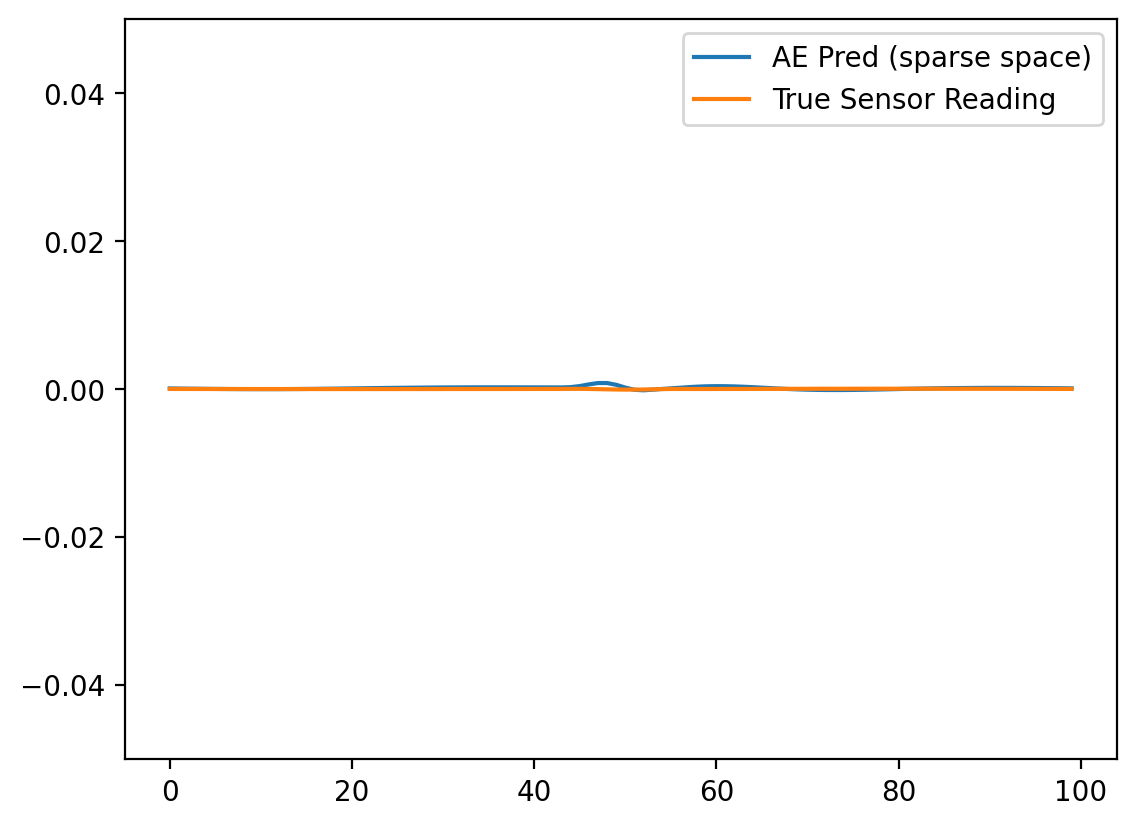

In [33]:
plt.figure(dpi=200)
plt.plot(FS_AE_sparse[sparse_par, :, sparse_sensor], label="AE Pred (sparse space)")
plt.plot(RS_reshaped[sparse_par, :, sparse_sensor], label="True Sensor Reading")
plt.ylim(-0.05, 0.05)
plt.legend()
plt.show()

##### Parameter distribution

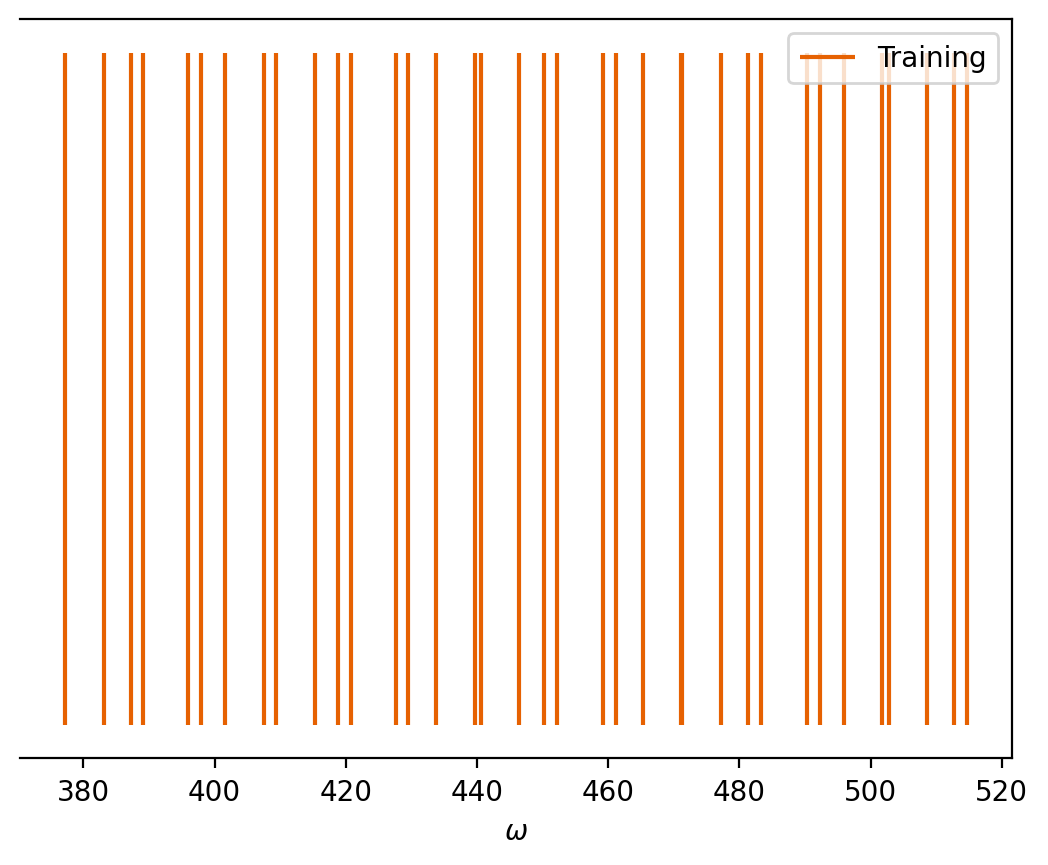

In [34]:
plt.figure(dpi=200)
plt.tight_layout()
plt.vlines(params_train[:, 0], ymin=-1, ymax=1, colors="#e66101", label="Training")
#plt.vlines(params_val[:, 0], ymin=-1, ymax=1, colors="#5e3c99", label="Validation")
#plt.vlines(params_test[:, 0], ymin=-1, ymax=1, colors="#fdb863", alpha=0.35, label="Testing")
plt.yticks([])
ax = plt.gca()
ax.spines['left'].set_visible(False)
plt.xlabel(r"$\omega$")
plt.legend(loc="upper right")
plt.show()

##### Time-series comparison

In [35]:
np.argmin(errs)

3

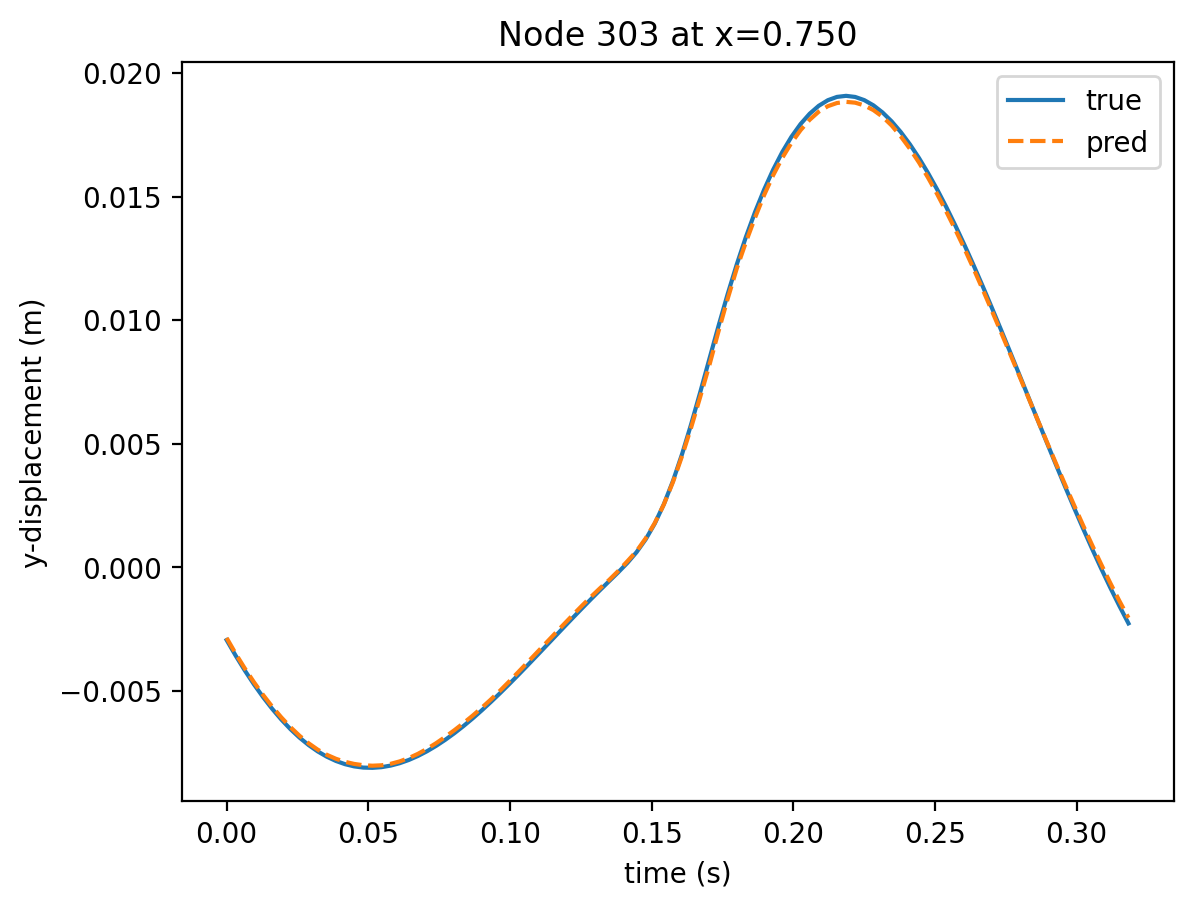

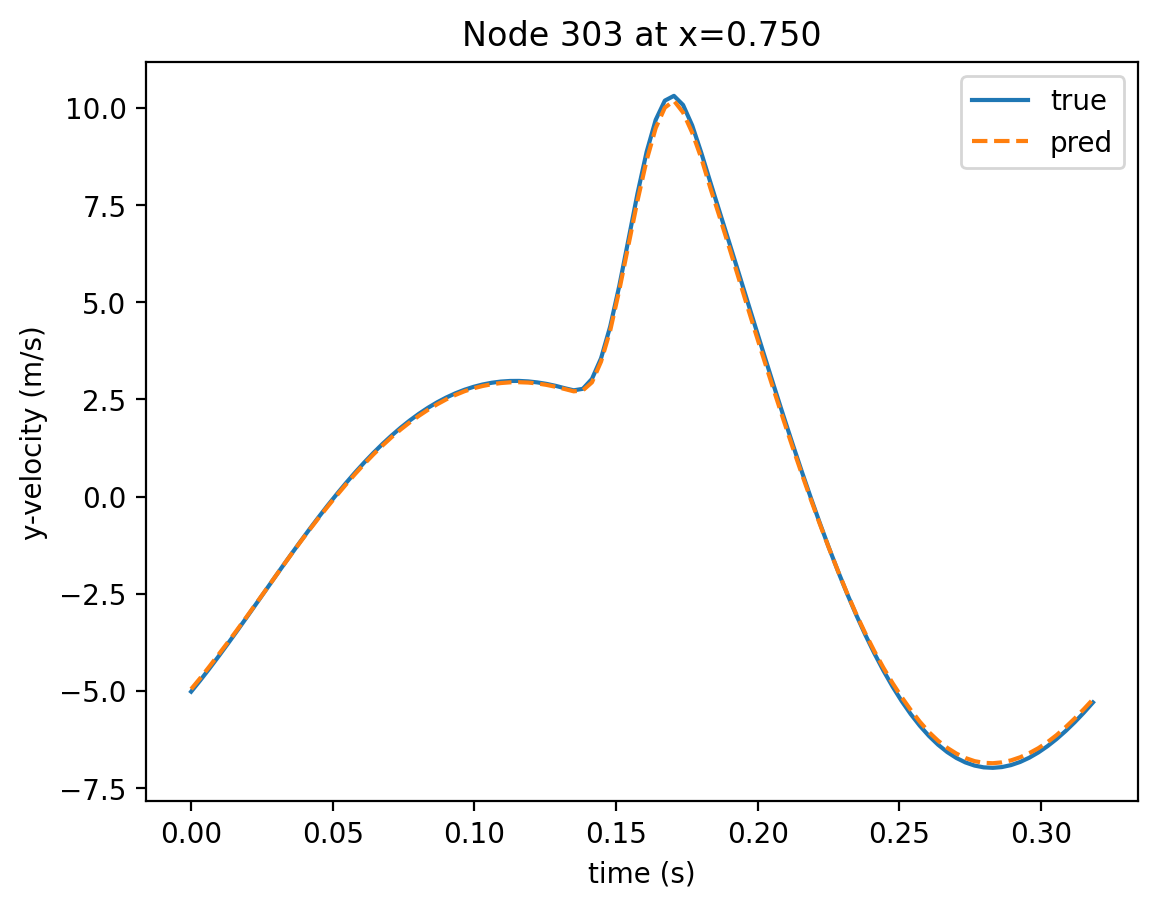

In [36]:
p = 6

# Displacement at the selected top-edge node/component
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, disp_idx]*disp_norm, label="true")
plt.plot(t, FS_pred[p, :, disp_idx]*disp_norm, '--', label="pred")
plt.ylabel(f"{plot_component_name}-displacement (m)")
plt.xlabel("time (s)")
plt.title(f"Node {plot_node_label} at x={plot_x_coord:.3f}")
plt.legend()
plt.show()

# Velocity at the same node/component
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, vel_idx]*vel_norm, label="true")
plt.plot(t, FS_pred[p, :, vel_idx]*vel_norm, '--', label="pred")
plt.ylabel(f"{plot_component_name}-velocity (m/s)")
plt.xlabel("time (s)")
plt.title(f"Node {plot_node_label} at x={plot_x_coord:.3f}")
plt.legend()
plt.show()

##### Phase-plane plots (4x4)

In [37]:
if hasattr(model.problem.nodes[4].nodes[0].callable.block, "q_lims"):
    # model.problem.nodes[4].nodes[0].callable.block is the old RBF NODE block in EDM
    rbf_block = model.problem.nodes[4].nodes[0].callable.block

    # pick a q-range
    q_min, q_max = params_test[:, 0].min(), params_test[:, 0].max()
    q_grid = np.linspace(q_min, q_max, 500, dtype=np.float32)

    # _rbf_weights expects shape [B, n_q]
    q_torch = torch.tensor(q_grid[:, None], dtype=torch.float32, device=rbf_block.q_centers.device)

    with torch.no_grad():
        w = rbf_block._rbf_weights(q_torch).cpu().numpy()
        rbf_weights = w

    plt.figure(dpi=200)
    for k in range(w.shape[1]):
        plt.plot(q_grid, w[:, k], label=f"expert {k}")
    plt.xlabel("q")
    plt.ylabel("RBF weight")
    plt.title("Expert activations")
    plt.legend()
    plt.show()


In [ ]:
# Phase-plane plots now use the same selected node/component as the time traces.

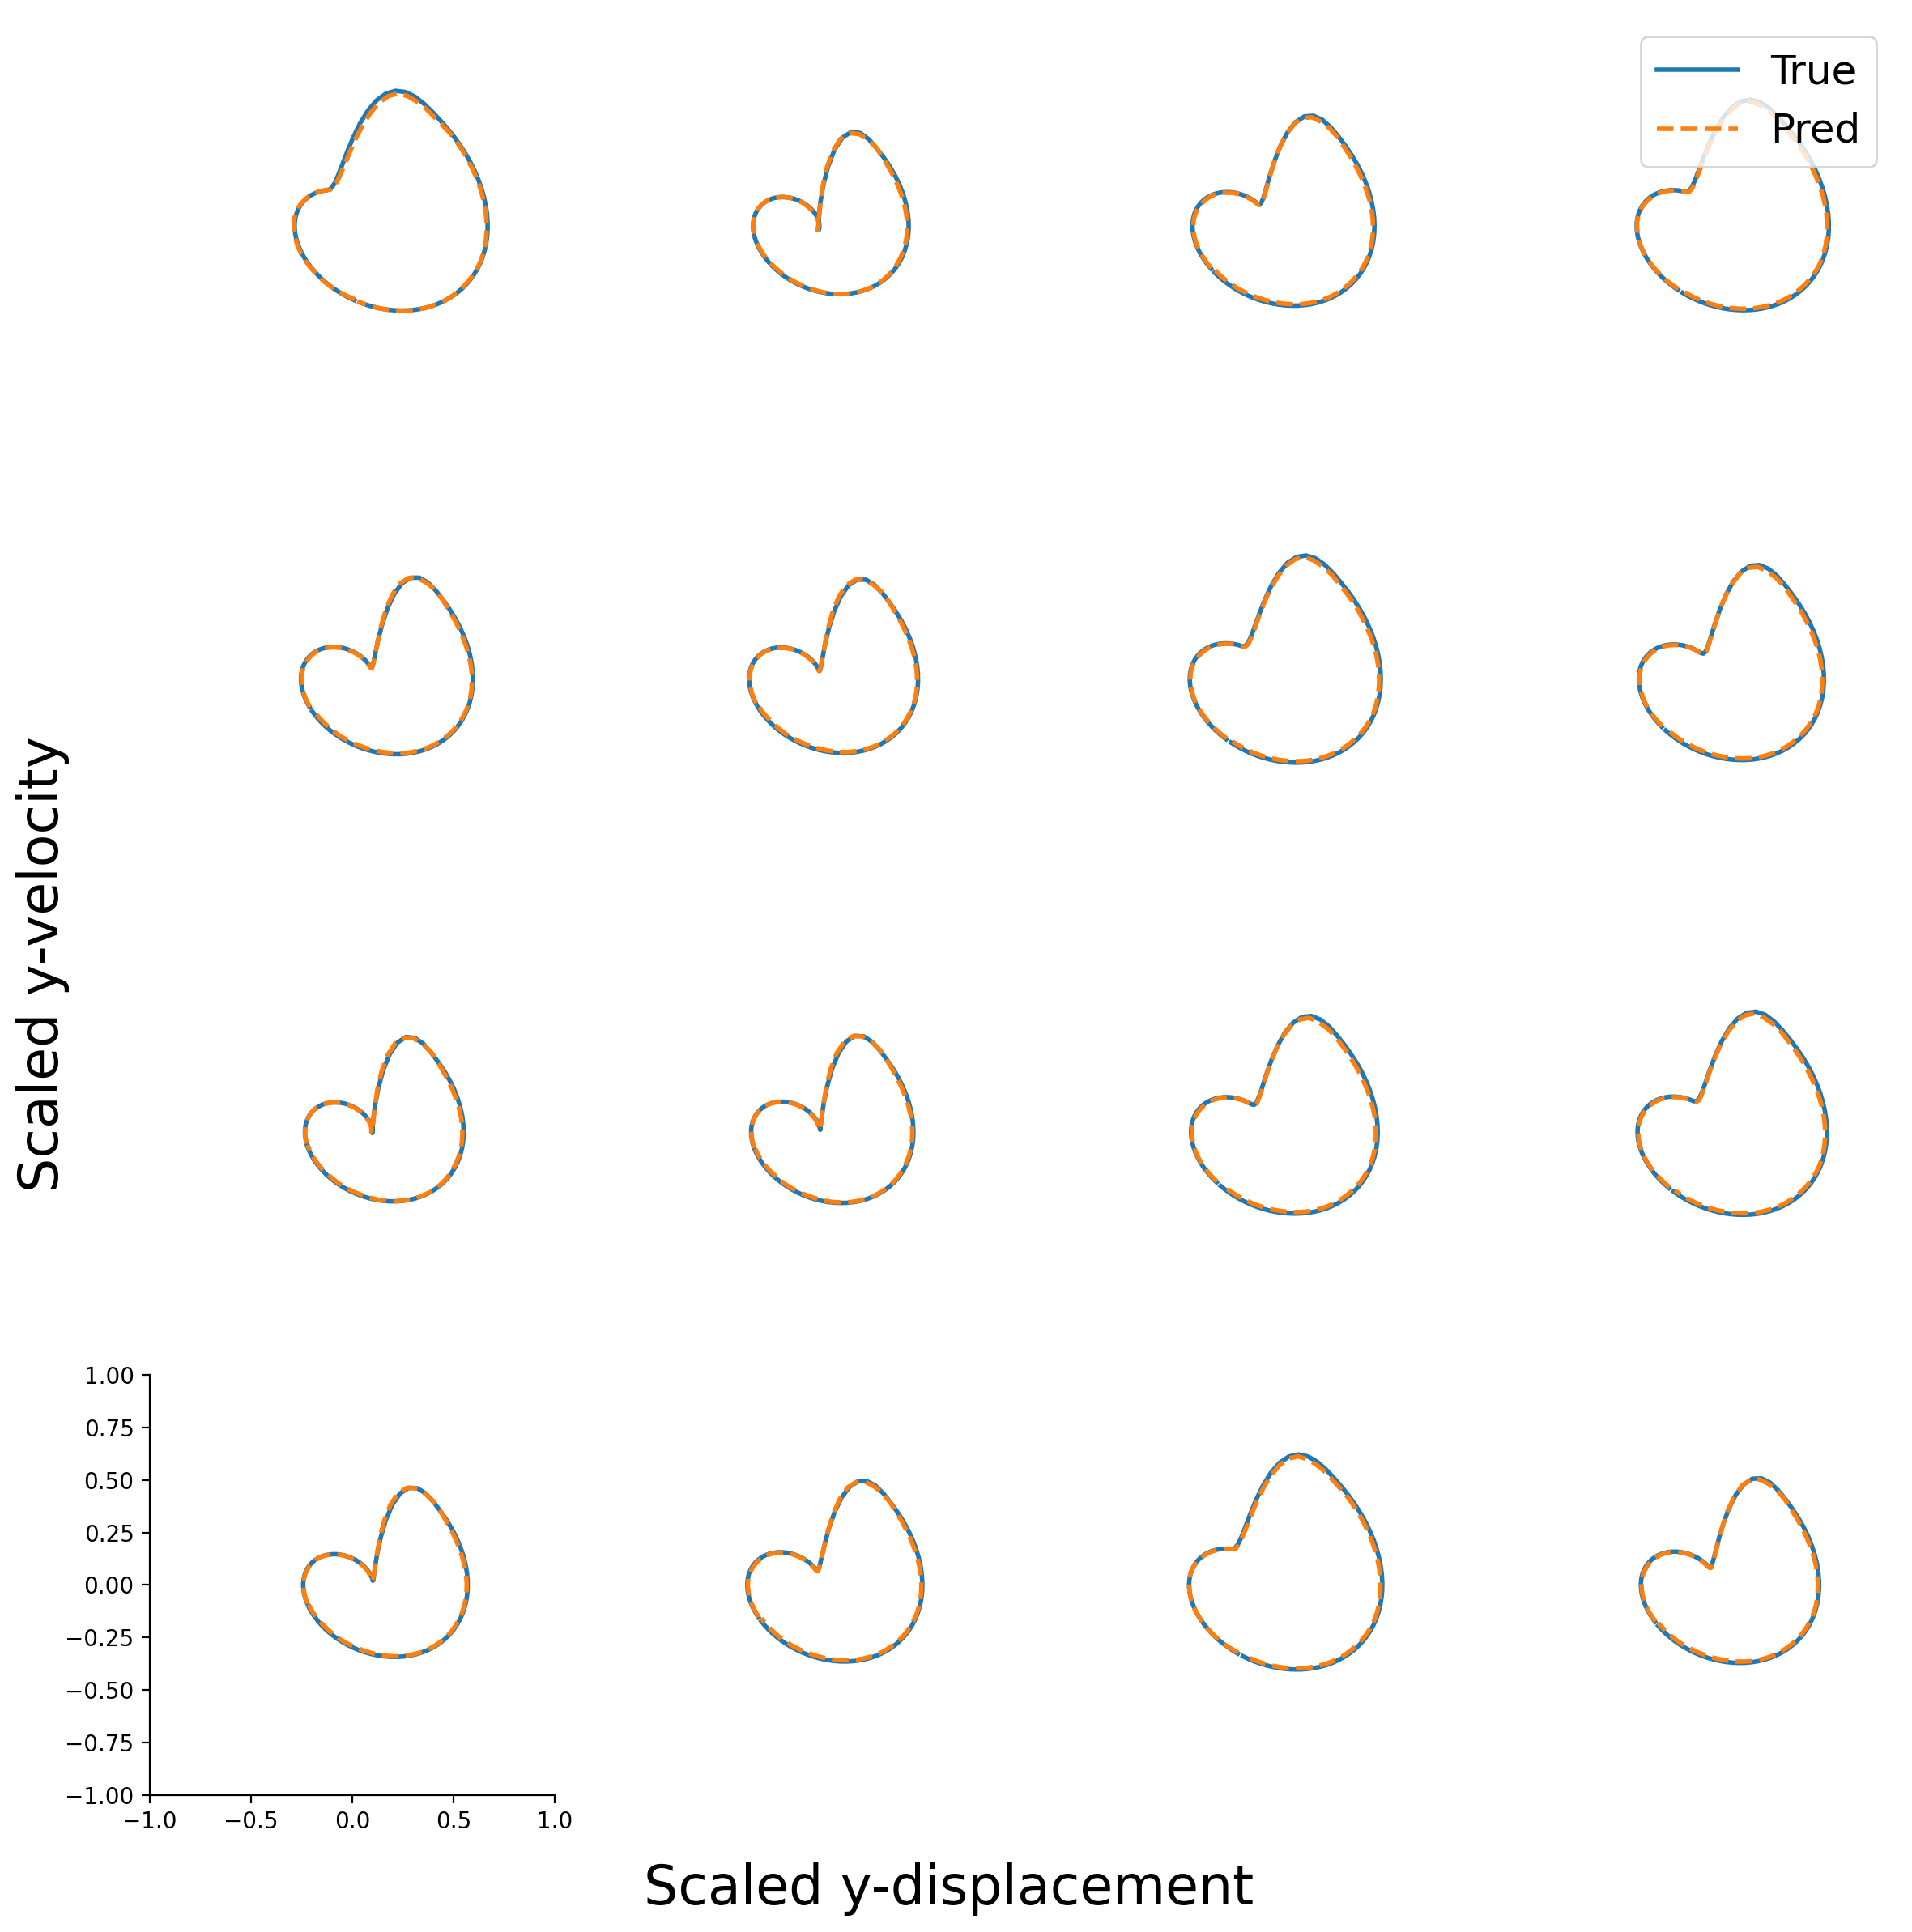

In [38]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12), dpi=200)
ind = np.linspace(0, min(15, FS_pred.shape[0] - 1), 16, dtype=np.int32)

it = 0
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        line1, = ax.plot(FS_reshaped[ind[it], :, disp_idx], FS_reshaped[ind[it], :, vel_idx], linewidth=2, label='True')
        line2, = ax.plot(FS_pred[ind[it], :, disp_idx], FS_pred[ind[it], :, vel_idx], '--', linewidth=2, label='Pred')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        ax.set_facecolor('none')
        for spine in ax.spines.values():
            spine.set_visible(False)
        if i == 3 and j == 0:
            ax.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
        if i == 0 and j == 3:
            ax.legend(handles=[line1, line2], loc='upper right', fontsize=18)
        it += 1

fig.supxlabel(f'Scaled {plot_component_name}-displacement', fontsize=24)
fig.supylabel(f'Scaled {plot_component_name}-velocity', fontsize=24)
plt.tight_layout()
plt.show()

##### Multi-cycle evaluation

In [39]:
num_cycles = 12
model.problem.nodes[4].nsteps = nt * num_cycles
model.problem.eval()

### MODEL SUMMARY ###

NODES:
  Encoder_x(x0) -> LS_x0
  Encoder_X(X) -> LS_X
  Noise(LS_x0) -> LS_x
  Control_Encoder(U) -> U
  System(
  (nodes): ModuleList(
    (0): NODE(LS_x, U, t) -> LS_x
  )
)
  Decoder_x(LS_x) -> x_hat
  Decoder_X(LS_X) -> X_hat
  FS_true(X) -> X_full
  FS_pred(x_hat) -> x_hat_full
  Grad_X(X_full) -> X_grad
  Grad_x(x_hat_full) -> x_hat_grad

CONSTRAINTS: none

OBJECTIVES:
  Constraint(
  (left): slice
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): X_hat
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): LS_X
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): -
  (right): -
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): X_grad
  (comparator): Eq()
)

In [40]:
idx = np.arange(min(4, RS_test.shape[0]))
RS_test_long = np.concatenate([RS_test[idx]] * num_cycles, axis=1)
ft_test_long = np.concatenate([ft_test[idx]] * num_cycles, axis=1)
t_cycle = np.ascontiguousarray(t[:, np.newaxis], dtype=np.float32)
t_long = np.concatenate([t_cycle] * num_cycles, axis=0)

test_data_long = {
    'X': torch.as_tensor(RS_test_long, dtype=torch.float32, device=device),
    'x0': torch.as_tensor(RS_test_long[:, 0:1], dtype=torch.float32, device=device),
    'U': torch.as_tensor(ft_test_long, dtype=torch.float32, device=device),
    't': torch.as_tensor(t_long, dtype=torch.float32, device=device).repeat(len(idx), 1, 1),
}

In [41]:
outputs_long = model.problem.step(test_data_long)

In [42]:
FS_reshaped_long = np.concatenate([FS_test[idx, i, :, :] for i in range(n_fields)], axis=-1)
FS_reshaped_long = np.concatenate([FS_reshaped_long] * num_cycles, axis=1)
RS_reshaped_long = np.concatenate([RS_test[idx]] * num_cycles, axis=1)

FS_AE_long_sparse = outputs_long['X_hat'].cpu().detach().numpy()
FS_AE_long_full = outputs_long['X_hat_full'].cpu().detach().numpy() if 'X_hat_full' in outputs_long else None

if 'x_hat_full' in outputs_long:
    FS_pred_long = outputs_long['x_hat_full'][:, :-1, :].cpu().detach().numpy()
else:
    FS_pred_long = outputs_long['x_hat'][:, :-1, :].cpu().detach().numpy()

In [43]:
long_ae_sparse_frob_error = np.linalg.norm(FS_AE_long_sparse - RS_reshaped_long) / np.linalg.norm(RS_reshaped_long)
long_ae_full_frob_error = None
if FS_AE_long_full is not None:
    long_ae_full_frob_error = np.linalg.norm(FS_AE_long_full - FS_reshaped_long) / np.linalg.norm(FS_reshaped_long)
long_node_full_frob_error = np.linalg.norm(FS_pred_long - FS_reshaped_long) / np.linalg.norm(FS_reshaped_long)

if long_ae_full_frob_error is not None:
    print(f"Frob norm for AE (full space) is : {long_ae_full_frob_error}")
else:
    print(f"Frob norm for AE (sparse space) is : {long_ae_sparse_frob_error}")
print(f"Frob norm for NODE (full space) is : {long_node_full_frob_error}")

Frob norm for AE (sparse space) is : 0.01728636585175991
Frob norm for NODE (full space) is : 0.07516313344240189


##### PSD comparison

In [44]:
from psd import psd_cutoff, psd_custom

In [45]:
lim = 300
psd_time = np.linspace(0, T * num_cycles, nt * num_cycles)
F_true, Pxx_true = psd_custom(psd_time, FS_reshaped_long[0, :, disp_idx])
F_pred, Pxx_pred = psd_custom(psd_time, FS_pred_long[0, :, disp_idx])

In [46]:
evaluation_export_report = write_evaluation_plot_bundle(globals())

Saved evaluation plotting arrays to c:\Users\haida\Desktop\EDM_NODE_w_2D\beam_node_optimized_hole_center_omega\Examples\elliptic_hole_omega\Outputs\model_checkpoint\1\evaluation_plot_data\evaluation_plot_data.npz
Saved evaluation plotting metadata to c:\Users\haida\Desktop\EDM_NODE_w_2D\beam_node_optimized_hole_center_omega\Examples\elliptic_hole_omega\Outputs\model_checkpoint\1\evaluation_plot_data\evaluation_plot_metadata.json
Skipped missing arrays: ['q_grid', 'rbf_weights', 'FS_AE_full', 'FS_AE_long_full']


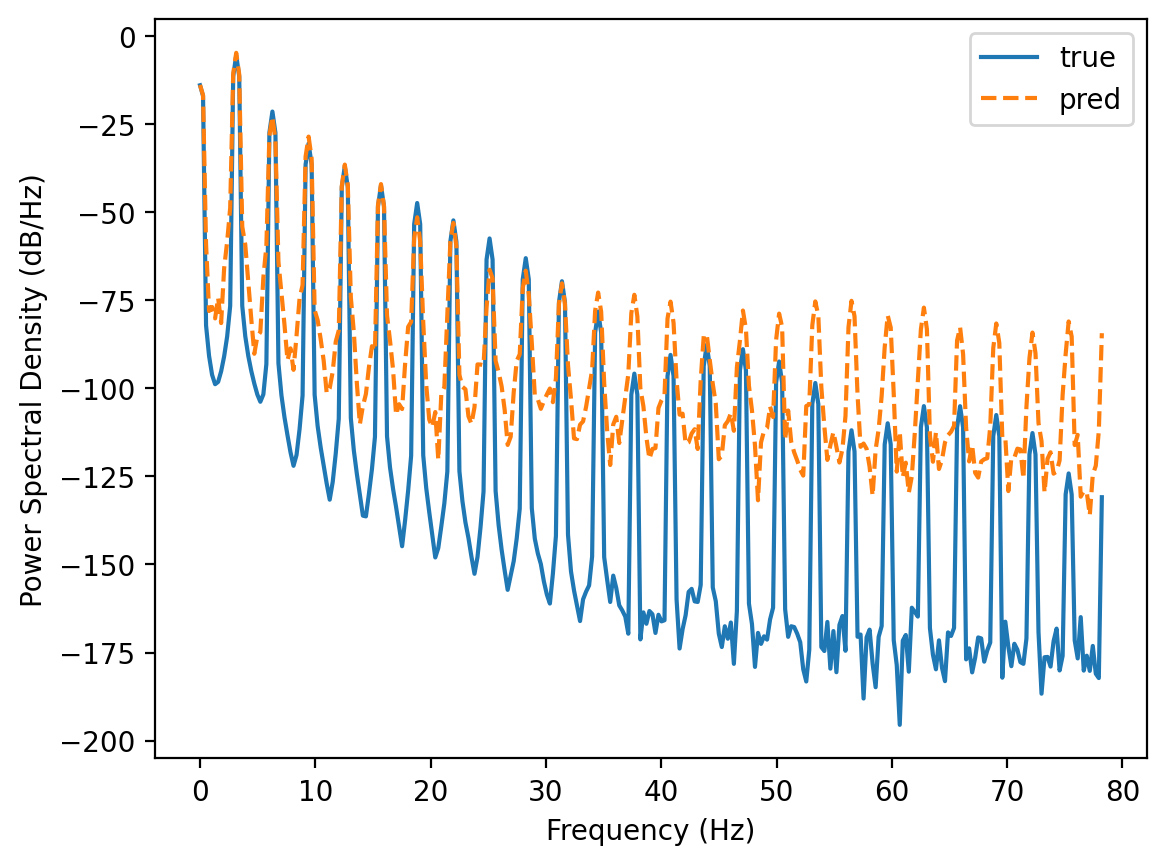

In [47]:
lim = 300
plt.figure(dpi=200)
plt.plot(F_true[:lim], Pxx_true[:lim], label='true')
plt.plot(F_pred[:lim], Pxx_pred[:lim], '--', label='pred')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.legend()
plt.show()

## Local phase-plane field plots



In [30]:


import os
from matplotlib import cm


def nearest_sparse_sensor_to_full_dof(full_dof_idx, sensor_placement, nx):
    sensor_full_idx = np.rint(np.asarray(sensor_placement) / 100.0 * (nx - 1)).astype(int)
    sensor_full_idx = np.clip(sensor_full_idx, 0, nx - 1)
    sparse_idx = int(np.argmin(np.abs(sensor_full_idx - int(full_dof_idx))))
    return sparse_idx, int(sensor_full_idx[sparse_idx]), sensor_full_idx


def _trajectory_limits(traj_1d, pad_frac=0.15):
    lo, hi = float(np.min(traj_1d)), float(np.max(traj_1d))
    pad = pad_frac * (hi - lo + 1e-12)
    return (lo - pad, hi + pad)


def derive_gate_windows(gate_weights, t, manual_bounds=None, min_len=2):
    """Partition the timeline into regime windows.

    Default: contiguous runs where the same expert has the max gate weight.
    manual_bounds: optional list of (start, end). Each entry is interpreted as time
        indices if > 1, else as fractions of the total horizon. Use this to force
        exactly pre/impulse/post, e.g. [(0.0, 0.45), (0.45, 0.55), (0.55, 1.0)].
    """
    t = np.asarray(t).reshape(-1)
    nt = len(t)
    windows = []
    if manual_bounds is not None:
        for k, (a, b) in enumerate(manual_bounds):
            ia = int(a) if a > 1 else int(round(a * (nt - 1)))
            ib = int(b) if b > 1 else int(round(b * (nt - 1)))
            ia, ib = max(0, ia), min(nt - 1, ib)
            idx = np.arange(ia, ib + 1)
            windows.append({"label": f"window {k}", "idx": idx,
                            "t_start": float(t[ia]), "t_end": float(t[ib])})
        return windows

    regime = np.argmax(np.asarray(gate_weights), axis=1)
    start = 0
    for i in range(1, nt + 1):
        if i == nt or regime[i] != regime[start]:
            idx = np.arange(start, i)
            if len(idx) >= min_len:
                windows.append({"label": f"expert {int(regime[start])}",
                                "expert": int(regime[start]), "idx": idx,
                                "t_start": float(t[idx[0]]), "t_end": float(t[idx[-1]])})
            start = i
    return windows


def _edm_velocity_per_point(model, states, forcing_rows, time_values, dt, device,
                            u_period_rows=None, max_tries=(1, 2, 3)):
    """dx/dt at a batch of states, each with its OWN forcing row and time value."""
    states = np.asarray(states, dtype=np.float32)
    forcing_rows = np.asarray(forcing_rows, dtype=np.float32)          # [B, nU]
    time_values = np.asarray(time_values, dtype=np.float32).reshape(-1)  # [B]
    B = states.shape[0]

    old_nsteps = getattr(model.problem.nodes[5], "nsteps", None)
    last_error = None
    try:
        for ns in max_tries:
            try:
                model.problem.nodes[5].nsteps = ns
                model.problem.eval()

                X = np.repeat(states[:, None, :], ns, axis=1)                 # [B, ns, D]
                U = np.repeat(forcing_rows[:, None, :], ns, axis=1)           # [B, ns, nU]
                tt = np.repeat(time_values[:, None, None], ns, axis=1)        # [B, ns, 1]

                batch = {
                    "X": torch.as_tensor(X, dtype=torch.float32, device=device),
                    "x0": torch.as_tensor(states[:, None, :], dtype=torch.float32, device=device),
                    "U": torch.as_tensor(U, dtype=torch.float32, device=device),
                    "t": torch.as_tensor(tt, dtype=torch.float32, device=device),
                }
                if u_period_rows is not None:
                    # Periodic history init: forcing cycle rolled to each
                    # grid point's assigned phase.
                    batch["U_period"] = torch.as_tensor(
                        u_period_rows, dtype=torch.float32, device=device)
                with torch.no_grad():
                    out = model.problem.step(batch)
                    xhat = out["x_hat"]
                if xhat.shape[1] >= 2:
                    dxdt = (xhat[:, 1, :] - xhat[:, 0, :]) / float(dt)
                else:
                    dxdt = (xhat[:, 0, :] - batch["x0"][:, 0, :]) / float(dt)
                return dxdt.detach().cpu().numpy()
            except Exception as exc:
                last_error = exc
                continue
        raise RuntimeError(f"field eval failed for nsteps in {max_tries}: {last_error!r}")
    finally:
        if old_nsteps is not None:
            model.problem.nodes[5].nsteps = old_nsteps
            model.problem.eval()


def compute_regime_field(model, RS_reference, ft_reference, t, dt, n_sparse, sensor_idx,
                         window, sample_idx, q_lim, v_lim, n_grid=45,
                         mask_dist=0.10, chunk_size=1024, qdot_scale=None, device=None):
    """Field for one gate window. Each grid point inherits time/forcing/other-state
    from its nearest within-window trajectory point; off-manifold points are masked."""
    if device is None:
        device = next(model.problem.parameters()).device
    s = int(sensor_idx)
    w_idx = window["idx"]

    traj_q = RS_reference[sample_idx, w_idx, s].astype(np.float32)
    traj_v = RS_reference[sample_idx, w_idx, n_sparse + s].astype(np.float32)

    qspan = (q_lim[1] - q_lim[0]) or 1.0
    vspan = (v_lim[1] - v_lim[0]) or 1.0

    q_grid = np.linspace(q_lim[0], q_lim[1], n_grid)
    v_grid = np.linspace(v_lim[0], v_lim[1], n_grid)
    Q, V = np.meshgrid(q_grid, v_grid)
    gq, gv = Q.ravel(), V.ravel()

    # Nearest within-window trajectory point, in normalized phase coords.
    dq = (gq[:, None] - traj_q[None, :]) / qspan
    dv = (gv[:, None] - traj_v[None, :]) / vspan
    d2 = dq * dq + dv * dv
    nn = np.argmin(d2, axis=1)
    nn_dist = np.sqrt(d2[np.arange(d2.shape[0]), nn])
    nn_time_idx = w_idx[nn]

    # Full base state per grid point = trajectory state at its assigned time, then
    # override the swept (q, qdot) for the selected sensor.
    grid_states = RS_reference[sample_idx, nn_time_idx, :].astype(np.float32).copy()
    grid_states[:, s] = gq
    grid_states[:, n_sparse + s] = gv

    forcing_rows = ft_reference[sample_idx, nn_time_idx, :].astype(np.float32)
    time_values = np.asarray(t).reshape(-1)[nn_time_idx].astype(np.float32)
    cycle = np.ascontiguousarray(ft_reference[sample_idx], dtype=np.float32)
    u_period_rows = np.stack([np.roll(cycle, -int(k), axis=0) for k in nn_time_idx])

    chunks = []
    for st in range(0, grid_states.shape[0], chunk_size):
        sp = min(st + chunk_size, grid_states.shape[0])
        chunks.append(_edm_velocity_per_point(model, grid_states[st:sp],
                                               forcing_rows[st:sp], time_values[st:sp],
                                               dt, device,
                                               u_period_rows=u_period_rows[st:sp]))
    dxdt = np.concatenate(chunks, axis=0)
    dQ = dxdt[:, s].reshape(Q.shape)
    dV = dxdt[:, n_sparse + s].reshape(Q.shape)
    if qdot_scale is not None:
        # Kinematic identity dq/dt = v * (vel_norm/disp_norm): exact for any
        # state, unlike the model's finite-differenced dQ, which is dominated
        # by AE reconstruction noise for small-amplitude sensors.
        dQ = V * float(qdot_scale)
    speed = np.sqrt(dQ ** 2 + dV ** 2)

    # Per-regime panels are conditioned on their window: a grid cell here means
    # "this regime's flow at (q, v)", so time-separated other passes do NOT
    # make the cell ambiguous (unlike the merged field, which keeps that mask).
    mask = (nn_dist > mask_dist).reshape(Q.shape)
    dQ = np.where(mask, np.nan, dQ)
    dV = np.where(mask, np.nan, dV)
    speed = np.where(mask, np.nan, speed)
    return {"Q": Q, "V": V, "dQ": dQ, "dV": dV, "speed": speed, "mask": mask,
            "traj_q": traj_q, "traj_v": traj_v, "w_idx": w_idx}


def plot_regime_phase_fields(model, RS_reference, ft_reference, t, dt, n_sparse,
                             gate_weights, full_dof_idx=None, sensor_idx=None,
                             RS_pred_sparse=None, nx=None, sensor_placement=None,
                             sample_idx=0, n_grid=45, mask_dist=0.10,
                             speed_clip_pct=99.0, manual_bounds=None, show_background=False,
                             savepath=None, qdot_scale=None, device=None):
    if sensor_idx is None:
        if full_dof_idx is None:
            raise ValueError("Provide sensor_idx or full_dof_idx.")
        if nx is None or sensor_placement is None:
            raise ValueError("full_dof_idx requires nx and sensor_placement.")
        sensor_idx, nearest_full_idx, _ = nearest_sparse_sensor_to_full_dof(
            full_dof_idx, sensor_placement, nx)
    else:
        nearest_full_idx = None
    s = int(sensor_idx)

    windows = derive_gate_windows(gate_weights, t, manual_bounds=manual_bounds)
    print(f"Derived {len(windows)} regime window(s):")
    for w in windows:
        print(f"  {w['label']}: idx[{w['idx'][0]}..{w['idx'][-1]}], "
              f"t in [{w['t_start']:.4g}, {w['t_end']:.4g}] s")

    # Shared axes from the full sample trajectory.
    q_lim = _trajectory_limits(RS_reference[sample_idx, :, s])
    v_lim = _trajectory_limits(RS_reference[sample_idx, :, n_sparse + s])

    fields = [compute_regime_field(model, RS_reference, ft_reference, t, dt, n_sparse, s,
                                   w, sample_idx, q_lim, v_lim, n_grid=n_grid,
                                   mask_dist=mask_dist, qdot_scale=qdot_scale,
                                   device=device) for w in windows]

    all_speed = np.concatenate([f["speed"][~np.isnan(f["speed"])].ravel()
                                for f in fields if np.any(~np.isnan(f["speed"]))])
    vmax = float(np.percentile(all_speed, speed_clip_pct)) if all_speed.size else 1.0
    vmax = vmax if vmax > 0 else 1.0
    levels = np.linspace(0.0, vmax, 25)

    nW = len(windows)
    fig, axes = plt.subplots(1, nW, figsize=(4.2 * nW, 4.0), dpi=200, squeeze=False)
    axes = axes[0]

    for ax, w, f in zip(axes, windows, fields):
        # faint full trajectory for context
        ax.plot(RS_reference[sample_idx, :, s], RS_reference[sample_idx, :, n_sparse + s],
                color="0.6", lw=0.5, alpha=0.5, zorder=0)

        if show_background:
            if np.any(~np.isnan(f["speed"])):
                Z = np.ma.masked_invalid(np.clip(f["speed"], 0.0, vmax))
                ax.contourf(f["Q"], f["V"], Z, levels=levels, cmap=cm.viridis,
                            alpha=0.75, extend="max")
        try:
            ax.streamplot(f["Q"], f["V"], f["dQ"], f["dV"], density=1.2,
                        color="black", linewidth=0.7, arrowsize=1.0)
        except Exception:
            ax.streamplot(f["Q"], f["V"], np.nan_to_num(f["dQ"]),
                        np.nan_to_num(f["dV"]), density=1.2, color="black",
                        linewidth=0.7, arrowsize=1.0)

        ax.plot(f["traj_q"], f["traj_v"], color="red", lw=1.5, label="true (window)")
        if RS_pred_sparse is not None:
            RS_pred_sparse = np.asarray(RS_pred_sparse)
            ax.plot(RS_pred_sparse[sample_idx, w["idx"], s],
                    RS_pred_sparse[sample_idx, w["idx"], n_sparse + s],
                    color="white", ls="--", lw=1.0, label="pred (window)")

        ax.set_xlim(q_lim); ax.set_ylim(v_lim)
        ax.set_title(f"{w['label']}\n t\u2208[{w['t_start']:.3g}, {w['t_end']:.3g}] s",
                     fontsize=9)
        ax.set_xlabel("sparse displacement")
        if ax is axes[0]:
            ax.set_ylabel("sparse velocity")
            ax.legend(fontsize=7, loc="best")

    if show_background:
        cbar = fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(0, vmax), cmap=cm.viridis),
                            ax=axes, shrink=0.8, pad=0.02)
        cbar.set_label(f"local speed (clip {speed_clip_pct:.0f}th pct)", rotation=270, labelpad=14)

    sup = f"EDM per-regime phase fields, sparse sensor {s}"
    if nearest_full_idx is not None:
        sup += f" (nearest full DOF {nearest_full_idx})"
    fig.suptitle(sup, fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if savepath is not None:
        os.makedirs(os.path.dirname(os.path.abspath(savepath)), exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Saved per-regime phase fields to {savepath}")
    plt.show()
    return {"windows": windows, "fields": fields, "q_lim": q_lim, "v_lim": v_lim}

In [31]:
from matplotlib.colors import ListedColormap, BoundaryNorm

def compute_merged_phase_field(model, RS_reference, ft_reference, t, dt, n_sparse,
                               sensor_idx, windows, sample_idx, q_lim, v_lim,
                               n_grid=60, mask_dist=0.10, chunk_size=1024,
                               qdot_scale=None, device=None):
    """Single field over the whole cycle: each grid point inherits time/forcing
    from its nearest trajectory point across ALL windows; regime = window index
    of the assigned time.  Off-manifold points are masked with NaN."""
    if device is None:
        device = next(model.problem.parameters()).device
    s = int(sensor_idx)
    t_arr = np.asarray(t).reshape(-1)
    nt_cycle = len(t_arr)

    win_of_t = np.full(nt_cycle, -1, dtype=int)
    for wi, w in enumerate(windows):
        win_of_t[w["idx"]] = wi

    traj_q = RS_reference[sample_idx, :, s].astype(np.float32)
    traj_v = RS_reference[sample_idx, :, n_sparse + s].astype(np.float32)

    qspan = (q_lim[1] - q_lim[0]) or 1.0
    vspan = (v_lim[1] - v_lim[0]) or 1.0
    q_grid = np.linspace(q_lim[0], q_lim[1], n_grid)
    v_grid = np.linspace(v_lim[0], v_lim[1], n_grid)
    Q, V = np.meshgrid(q_grid, v_grid)
    gq, gv = Q.ravel(), V.ravel()

    dq = (gq[:, None] - traj_q[None, :]) / qspan
    dv = (gv[:, None] - traj_v[None, :]) / vspan
    d2 = dq * dq + dv * dv
    nn_time_idx = np.argmin(d2, axis=1)
    nn_dist = np.sqrt(d2[np.arange(d2.shape[0]), nn_time_idx])

    # Pass-ambiguity: cells where a time-separated pass of the orbit is ALSO
    # within mask_dist cannot be represented by a single-valued field -> mask.
    tsep = np.abs(np.arange(nt_cycle)[None, :] - nn_time_idx[:, None])
    tsep = np.minimum(tsep, nt_cycle - tsep)
    d2_other = np.where(tsep > nt_cycle // 10, d2, np.inf)
    other_dist = np.sqrt(d2_other.min(axis=1))
    ambiguous = (nn_dist <= mask_dist) & (other_dist <= mask_dist)

    grid_states = RS_reference[sample_idx, nn_time_idx, :].astype(np.float32).copy()
    grid_states[:, s] = gq
    grid_states[:, n_sparse + s] = gv
    forcing_rows = ft_reference[sample_idx, nn_time_idx, :].astype(np.float32)
    time_values = t_arr[nn_time_idx].astype(np.float32)
    cycle = np.ascontiguousarray(ft_reference[sample_idx], dtype=np.float32)
    u_period_rows = np.stack([np.roll(cycle, -int(k), axis=0) for k in nn_time_idx])

    chunks = []
    for st in range(0, grid_states.shape[0], chunk_size):
        sp = min(st + chunk_size, grid_states.shape[0])
        chunks.append(_edm_velocity_per_point(model, grid_states[st:sp],
                                               forcing_rows[st:sp], time_values[st:sp],
                                               dt, device,
                                               u_period_rows=u_period_rows[st:sp]))
    dxdt = np.concatenate(chunks, axis=0)
    dQ = dxdt[:, s].reshape(Q.shape)
    dV = dxdt[:, n_sparse + s].reshape(Q.shape)
    if qdot_scale is not None:
        # Kinematic identity dq/dt = v * (vel_norm/disp_norm); see
        # compute_regime_field.
        dQ = V * float(qdot_scale)
    speed = np.sqrt(dQ ** 2 + dV ** 2)

    mask = ((nn_dist > mask_dist) | ambiguous).reshape(Q.shape)
    regime = win_of_t[nn_time_idx].astype(np.float32).reshape(Q.shape)
    time_map = nn_time_idx.astype(np.float32).reshape(Q.shape)
    regime[mask] = np.nan
    time_map[mask] = np.nan
    dQ = np.where(mask, np.nan, dQ)
    dV = np.where(mask, np.nan, dV)
    speed = np.where(mask, np.nan, speed)
    return {"Q": Q, "V": V, "dQ": dQ, "dV": dV, "speed": speed, "mask": mask,
            "regime": regime, "time_map": time_map,
            "traj_q": traj_q, "traj_v": traj_v, "win_of_t": win_of_t}


def merge_and_save_phase_fields(model, RS_reference, ft_reference, t, dt, n_sparse,
                                gate_weights, sensor_idx=None, full_dof_idx=None,
                                RS_pred_sparse=None, nx=None, sensor_placement=None,
                                sample_idx=0, n_grid=60, mask_dist=0.10,
                                speed_clip_pct=99.0, manual_bounds=None,
                                regime_fields=None, save_dir=None, tag=None,
                                show_background=False, stream_color="black",
                                qdot_scale=None, device=None):
    """Merged phase field + saved values.

    show_background : if True, draw the speed gradient contourf + colorbar; if False
                      (default) the panel is just streamlines + trajectory.
    stream_color    : "black" for uniform streamlines, or "expert" to color each
                      streamline by the regime/expert governing that region (same
                      tab10 colors as the per-window trajectory segments).
    """
    if save_dir is None:
        save_dir = evaluation_plot_data_dir
    os.makedirs(save_dir, exist_ok=True)

    if sensor_idx is None:
        if full_dof_idx is None or nx is None or sensor_placement is None:
            raise ValueError("Provide sensor_idx, or full_dof_idx with nx and sensor_placement.")
        sensor_idx, nearest_full_idx, _ = nearest_sparse_sensor_to_full_dof(
            full_dof_idx, sensor_placement, nx)
    else:
        nearest_full_idx = None
    s = int(sensor_idx)
    if tag is None:
        tag = f"cluster{cluster}_sample{sample_idx}_sensor{s}"

    windows = derive_gate_windows(gate_weights, t, manual_bounds=manual_bounds)
    nW = len(windows)
    q_lim = _trajectory_limits(RS_reference[sample_idx, :, s])
    v_lim = _trajectory_limits(RS_reference[sample_idx, :, n_sparse + s])

    merged = compute_merged_phase_field(model, RS_reference, ft_reference, t, dt, n_sparse,
                                        s, windows, sample_idx, q_lim, v_lim,
                                        n_grid=n_grid, mask_dist=mask_dist,
                                        qdot_scale=qdot_scale, device=device)

    cmap_w = cm.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(5.4, 4.6), dpi=200)

    # ---- optional speed background ----
    if show_background:
        valid = merged["speed"][~np.isnan(merged["speed"])]
        vmax = float(np.percentile(valid, speed_clip_pct)) if valid.size else 1.0
        vmax = vmax if vmax > 0 else 1.0
        levels = np.linspace(0.0, vmax, 25)
        Z = np.ma.masked_invalid(np.clip(merged["speed"], 0.0, vmax))
        ax.contourf(merged["Q"], merged["V"], Z, levels=levels, cmap=cm.viridis,
                    alpha=0.75, extend="max")

    # ---- streamlines: black, or one solid-colored streamplot per expert ----
    stream_kw = dict(density=1.3, linewidth=0.7, arrowsize=1.0)
    if stream_color == "expert":
        regime = merged["regime"]            # float grid with NaN off-manifold
        for wi in range(nW):
            sel = (regime == wi)             # NaN == wi -> False, so masked cells excluded
            if sel.sum() < 4:                # too few cells to integrate cleanly
                continue
            uu = np.where(sel, merged["dQ"], np.nan)
            vv = np.where(sel, merged["dV"], np.nan)
            try:
                ax.streamplot(merged["Q"], merged["V"], uu, vv,
                              color=cmap_w(wi % 10), **stream_kw)
            except Exception:
                # fallback: zero-fill the holes so the integrator has a defined field
                ax.streamplot(merged["Q"], merged["V"],
                              np.nan_to_num(uu), np.nan_to_num(vv),
                              color=cmap_w(wi % 10), **stream_kw)
    else:  # "black"
        try:
            ax.streamplot(merged["Q"], merged["V"], merged["dQ"], merged["dV"],
                          color="black", **stream_kw)
        except Exception:
            ax.streamplot(merged["Q"], merged["V"], np.nan_to_num(merged["dQ"]),
                          np.nan_to_num(merged["dV"]), color="black", **stream_kw)

    # ---- trajectory colored by regime (legend) + optional pred ----
    for wi, w in enumerate(windows):
        ax.plot(RS_reference[sample_idx, w["idx"], s],
                RS_reference[sample_idx, w["idx"], n_sparse + s],
                color=cmap_w(wi % 10), lw=1.6, label=w["label"])
    if RS_pred_sparse is not None:
        RS_pred_sparse = np.asarray(RS_pred_sparse)
        ax.plot(RS_pred_sparse[sample_idx, :, s], RS_pred_sparse[sample_idx, :, n_sparse + s],
                color="0.3", ls="--", lw=1.0, label="true")

    ax.set_xlim(q_lim); ax.set_ylim(v_lim)
    ax.set_xlabel("sparse displacement"); ax.set_ylabel("sparse velocity")
    ttl = f"Merged EDM phase field, sparse sensor {s}"
    if nearest_full_idx is not None:
        ttl += f" (nearest full DOF {nearest_full_idx})"
    ax.set_title(ttl, fontsize=10)
    ax.legend(fontsize=7, loc="best")

    if show_background:
        cbar = fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(0, vmax), cmap=cm.viridis),
                            ax=ax, shrink=0.85, pad=0.03)
        cbar.set_label(f"local speed (clip {speed_clip_pct:.0f}th pct)",
                       rotation=270, labelpad=14)
    fig.tight_layout()

    merged_png = os.path.join(save_dir, f"phase_field_merged_{tag}.png")
    fig.savefig(merged_png, dpi=300, bbox_inches="tight")
    plt.show()

    # ---- value bundle (unchanged) ----
    npz_payload = {
        "merged_Q": merged["Q"].astype(np.float32),
        "merged_V": merged["V"].astype(np.float32),
        "merged_dQ": merged["dQ"].astype(np.float32),
        "merged_dV": merged["dV"].astype(np.float32),
        "merged_speed": merged["speed"].astype(np.float32),
        "merged_regime": merged["regime"].astype(np.float32),
        "merged_time_map": merged["time_map"].astype(np.float32),
        "merged_mask": merged["mask"],
        "traj_q": merged["traj_q"], "traj_v": merged["traj_v"],
        "win_of_t": merged["win_of_t"],
        "q_lim": np.asarray(q_lim, np.float32), "v_lim": np.asarray(v_lim, np.float32),
    }
    if regime_fields is not None:
        for wi, f in enumerate(regime_fields):
            for k in ("Q", "V", "dQ", "dV", "speed", "mask"):
                npz_payload[f"win{wi}_{k}"] = np.asarray(f[k]).astype(
                    np.float32 if k != "mask" else bool)

    npz_path = os.path.join(save_dir, f"phase_field_bundle_{tag}.npz")
    np.savez_compressed(npz_path, **npz_payload)

    meta = {"tag": tag, "sensor_idx": s, "nearest_full_idx": nearest_full_idx,
            "sample_idx": int(sample_idx), "n_grid": int(n_grid),
            "mask_dist": float(mask_dist), "speed_clip_pct": float(speed_clip_pct),
            "show_background": bool(show_background), "stream_color": stream_color,
            "q_lim": [float(q_lim[0]), float(q_lim[1])],
            "v_lim": [float(v_lim[0]), float(v_lim[1])],
            "windows": [{"label": w["label"], "idx_start": int(w["idx"][0]),
                         "idx_end": int(w["idx"][-1]), "t_start": w["t_start"],
                         "t_end": w["t_end"]} for w in windows],
            "merged_png": os.path.abspath(merged_png),
            "npz_path": os.path.abspath(npz_path),
            "arrays": {k: list(np.asarray(v).shape) for k, v in npz_payload.items()}}
    meta_path = os.path.join(save_dir, f"phase_field_bundle_{tag}.json")
    with open(meta_path, "w", encoding="utf-8") as fp:
        json.dump(meta, fp, indent=2)

    print(f"Saved merged figure -> {merged_png}")
    print(f"Saved value bundle  -> {npz_path}")
    print(f"Saved metadata      -> {meta_path}")
    return {"merged": merged, "windows": windows, "merged_png": merged_png,
            "npz_path": npz_path, "meta_path": meta_path}

kinematic calibration: qdot_scale=23.11, corr(FD q, v)=1.000
Derived 3 regime window(s):
  expert 0: idx[0..45], t in [0, 0.1447] s
  expert 1: idx[47..53], t in [0.1511, 0.1704] s
  expert 2: idx[54..98], t in [0.1736, 0.3151] s
Saved per-regime phase fields to C:\Users\haida\Desktop\gated_node_lab\tests\phase_fields\phase_field_panels_cluster1_sample0_sensor1.png


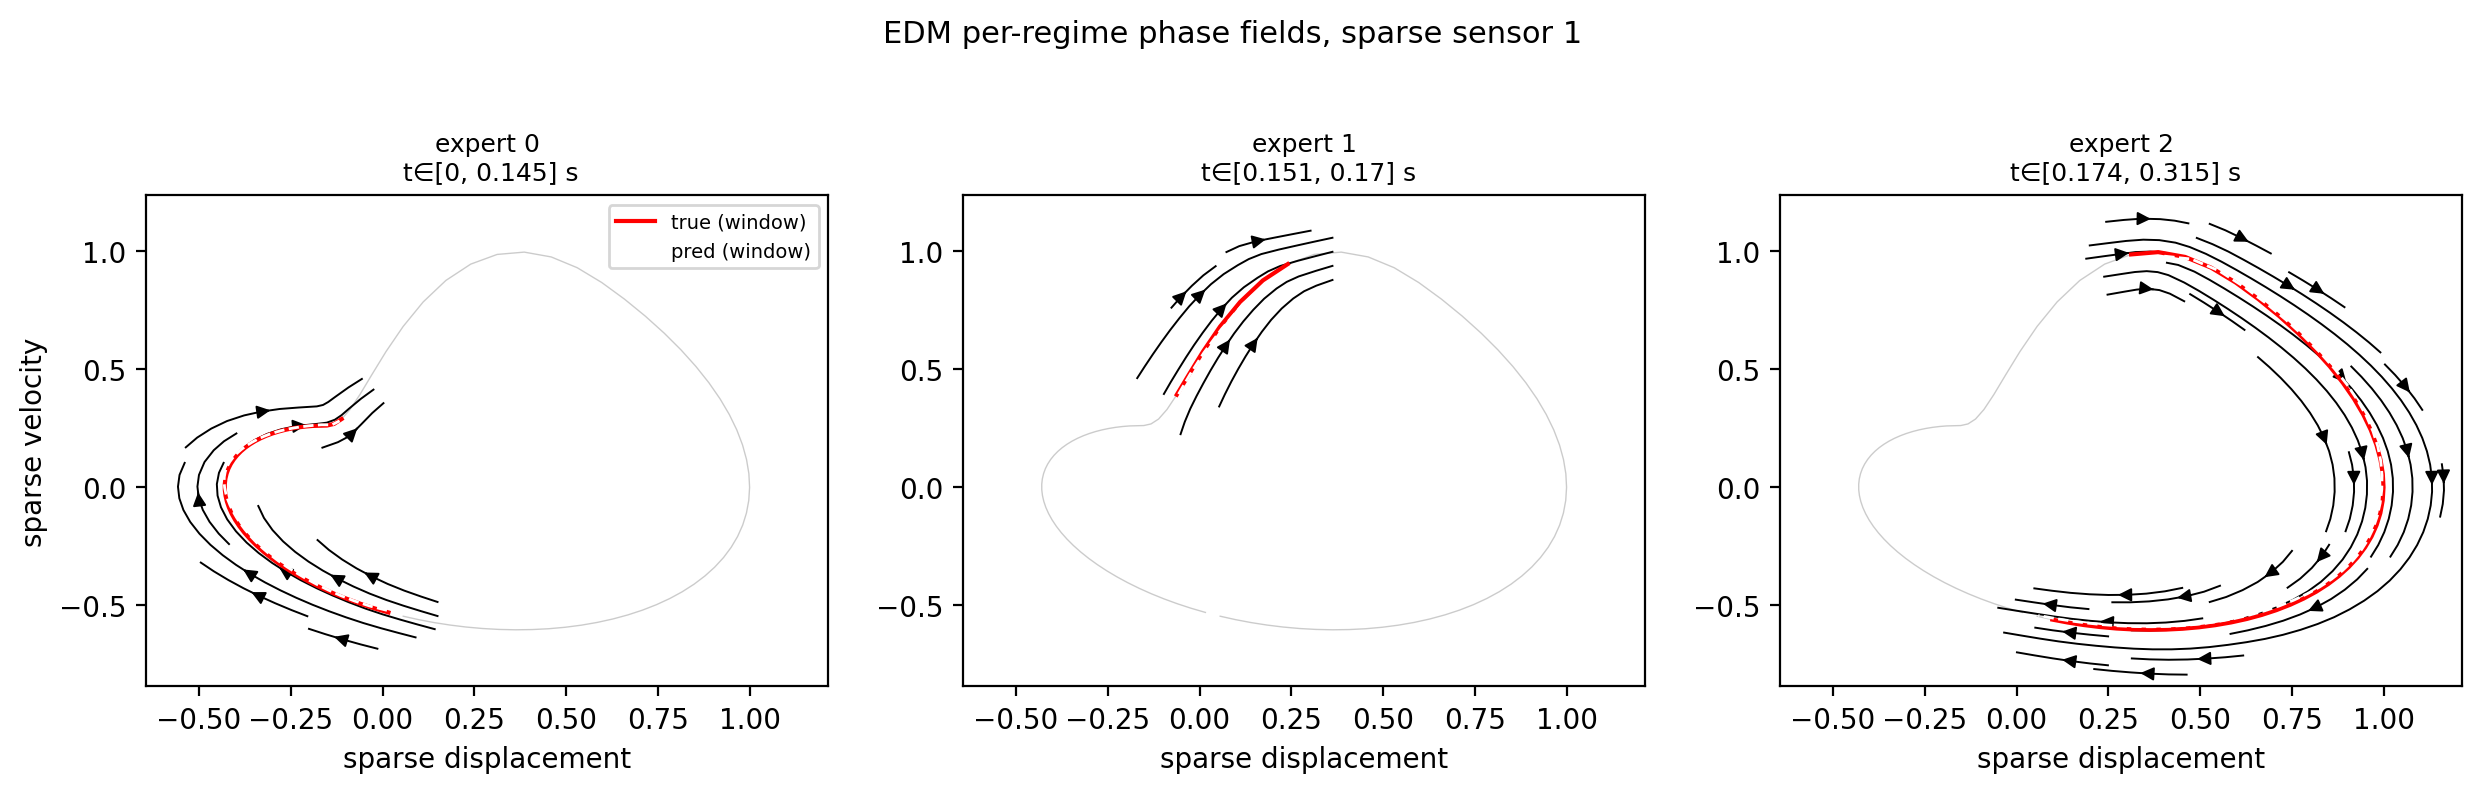

In [33]:
# %% Per-regime and merged phase fields (2-D mesh: pick a sparse sensor directly).
# The GateProbe in the corrected graph produces per-trajectory gate weights.
if "gate_w" not in outputs:
    raise KeyError(
        "gate_w was not produced. Confirm the model was built with "
        "method='rbf_moe' and that the single-cycle evaluation cell ran."
    )
gate_weights_traj = outputs["gate_w"].detach().cpu().numpy()   # [n_traj, nt, K]
RS_pred_sparse = outputs["x_hat"][:, :-1, :].detach().cpu().numpy()

p = 0
# Pick the sparse sensor with the largest displacement amplitude: small-amplitude
# sensors sit near the AE error floor and give noisy phase fields.
s = int(np.abs(RS_test[p, :, :n_sparse]).max(axis=0).argmax())
# Kinematic horizontal component: dq/dt = v * qdot_scale.  The scale is
# calibrated from the data itself (stored velocity units can carry constant
# factors that the norm ratio vel_norm/disp_norm does not capture).
_q_traj = RS_test[p, :, s]
_v_traj = RS_test[p, :, n_sparse + s]
_fd = np.gradient(_q_traj, dt)
qdot_scale = float((_fd @ _v_traj) / (_v_traj @ _v_traj + 1e-12))
_corr = float(np.corrcoef(_fd, _v_traj)[0, 1])
print(f'kinematic calibration: qdot_scale={qdot_scale:.2f}, corr(FD q, v)={_corr:.3f}')
if _corr < 0.95:
    print('WARNING: q and v are weakly conjugate at this sensor; '
          'falling back to the model dQ (qdot_scale=None).')
    qdot_scale = None
tag = f"cluster{cluster}_sample{p}_sensor{s}"

evaluation_plot_data_dir = os.path.join("C:\\Users\\haida\\Desktop\\gated_node_lab\\tests", "phase_fields")
panel_out = plot_regime_phase_fields(
    model=model, RS_reference=RS_test, ft_reference=ft_test, t=t, dt=dt,
    n_sparse=n_sparse, gate_weights=gate_weights_traj[p], sensor_idx=s,
    RS_pred_sparse=RS_pred_sparse, sample_idx=p, n_grid=45, mask_dist=0.10,
    manual_bounds=None, show_background=False, qdot_scale=qdot_scale,
    savepath=os.path.join(evaluation_plot_data_dir, f"phase_field_panels_{tag}.png"),
    device=device,
)


In [ ]:
merge_out = merge_and_save_phase_fields(
    model=model, RS_reference=RS_test, ft_reference=ft_test, t=t, dt=dt,
    n_sparse=n_sparse, gate_weights=gate_weights_traj[p], sensor_idx=s,
    RS_pred_sparse=RS_pred_sparse, sample_idx=p, n_grid=60, mask_dist=0.1,
    regime_fields=panel_out["fields"], tag=tag, qdot_scale=qdot_scale,
    show_background=False,      # True to bring the speed gradient back
    stream_color="expert",      # or "black"
    device=device,
)
